# Distributed Portfolio Optimization via Divide-and-Conquer QAOA on CUDA-Q

This notebook walks through an end-to-end pipeline that uses the
**Quantum Approximate Optimization Algorithm (QAOA)** — distributed across
multiple GPUs via NVIDIA's CUDA-Q framework — to solve a real
**Markowitz portfolio optimization** problem on S&P 500 stocks.

## What you will learn

1. **Data pipeline** — fetching real stock data and computing the financial
   inputs Markowitz needs (expected returns, covariance, correlation).
2. **QUBO formulation** — turning a constrained optimization problem into
   a *Quadratic Unconstrained Binary Optimization* form a quantum computer
   can solve.
3. **Ising mapping** — translating the QUBO into a Hamiltonian whose
   ground state is the optimal portfolio.
4. **Stock clustering** — using hierarchical clustering on the correlation
   matrix to split a 15-qubit problem into smaller, parallelizable
   subproblems.
5. **QAOA** — the quantum algorithm itself: how the circuit is built,
   what its parameters mean, and how a classical optimizer drives it.
6. **Distributed execution** — running the per-cluster QAOA in parallel
   across 4 GPUs using CUDA-Q's MQPU backend.
7. **Merging** — recombining the sub-portfolios into a global solution
   and refining it with greedy local search.

## Prerequisites

- **Quantum**: qubits, single-qubit gates (H, Rx, Rz), two-qubit gates
  (CNOT), and the idea of measuring in the Z basis.
- **Python**: numpy, basic plotting.

You do **not** need a finance background — Section 2 covers the relevant
concepts from scratch. Run this notebook from the project root so that
`from src.X import ...` resolves.


## 2. The Portfolio Optimization Problem

Suppose you have a universe of $N$ stocks and a budget to pick exactly $B$
of them. You want to maximise expected return while minimising risk. This
is the classical **Markowitz mean-variance** problem.

Let $x \in \{0, 1\}^N$ be a binary selection vector ($x_i = 1$ means we
hold stock $i$, otherwise $0$). Let

- $\mu \in \mathbb{R}^N$ — vector of (annualised) expected returns,
- $\Sigma \in \mathbb{R}^{N \times N}$ — covariance matrix of returns.

The portfolio's expected return is $\mu^\top x$ and its variance is
$x^\top \Sigma x$. Markowitz balances the two with a risk-aversion
parameter $q \ge 0$:

$$
\min_{x \in \{0,1\}^N} \;\; -\mu^\top x + q \, x^\top \Sigma x
\qquad \text{subject to} \qquad \sum_i x_i = B.
$$

When $q$ is small we focus on returns; when $q$ is large we focus on
diversification. The budget constraint forces us to pick exactly $B$
assets — without it, the optimum is the empty portfolio (no risk).

References for this section: **[1]** Markowitz (1952), **[2]** Buonaiuto
et al. (2023). Full details in Section 11.


## 3. Data Pipeline

We use **15 stocks** drawn from 5 sectors (3 tickers each), giving the
clustering step something interesting to find while keeping the qubit
count manageable:

| Sector              | Tickers                |
|---------------------|------------------------|
| Tech                | AAPL, MSFT, GOOGL      |
| Finance             | JPM, GS, BAC           |
| Energy              | XOM, CVX, COP          |
| Healthcare          | JNJ, PFE, UNH          |
| Consumer staples    | PG, KO, WMT            |

The window is **2022-01-01 to 2024-12-31** — three years, covering both
the 2022 bear market and the 2023–2024 rally, so the covariance estimate
isn't dominated by a single regime.

First, set up the path and import core scientific Python.


In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)


Fetch daily adjusted closing prices for the 15 tickers via `yfinance`.
This makes a network call.


In [2]:
from src.data_pipeline import (
    fetch_stock_data, compute_log_returns, compute_financial_metrics,
    TICKERS, START_DATE, END_DATE,
)

print(f"Fetching {len(TICKERS)} tickers from {START_DATE} to {END_DATE}...")
prices = fetch_stock_data(TICKERS, START_DATE, END_DATE)
print(f"Prices shape: {prices.shape}")
prices.head()


Fetching 15 tickers from 2022-01-01 to 2024-12-31...


[                       0%                       ]

[**********            20%                       ]  3 of 15 completed

[*************         27%                       ]  4 of 15 completed

[*******************   40%                       ]  6 of 15 completed

...

[**********************87%*****************      ]  13 of 15 completed

[**********************93%********************   ]  14 of 15 completed

[*********************100%***********************]  15 of 15 completed

Prices shape: (752, 15)


Ticker,AAPL,MSFT,GOOGL,JPM,GS,BAC,XOM,CVX,COP,JNJ,PFE,UNH,PG,KO,WMT
Date,,,,,,,,,,,,,,,
2022-01-03,178.103668,323.160828,143.802979,144.191559,355.345673,41.479748,54.760242,100.499313,63.208134,151.770035,45.365726,465.858154,145.227325,52.267666,45.671680
2022-01-04,175.843277,317.619537,143.215820,149.657883,366.266785,43.105526,56.819988,102.327950,65.949974,151.363083,43.668003,455.303375,145.735474,53.140255,44.834969
2022-01-05,171.165848,305.426758,136.645615,146.921799,358.311859,42.377968,57.526680,102.993683,64.818985,152.371689,44.548897,454.181122,146.395233,53.580971,45.441185
2022-01-06,168.308487,303.013336,136.618347,148.482697,356.783875,43.231281,58.879749,103.870071,67.252365,151.849686,43.916248,435.594269,145.164948,53.298912,45.314896
2022-01-07,168.474838,303.167786,135.893845,149.953918,357.305145,44.174408,59.362362,105.361633,69.094551,153.902298,44.620979,425.345520,145.084671,53.175526,45.747463


### Why log returns instead of simple returns?

Given a price series $P_t$, two natural definitions of one-period return
are:

- **Simple return:** $r_t = (P_t - P_{t-1}) / P_{t-1}$.
- **Log return:** $\ell_t = \ln(P_t / P_{t-1})$.

Quants almost always use log returns, for four reasons:

1. **Time-additivity.** Multi-day log return $\ln(P_{t+k}/P_t)$ equals the
   sum $\ell_{t+1} + \ell_{t+2} + \cdots + \ell_{t+k}$. Simple returns
   compound (multiply), they don't add — so you can't average them.
2. **Symmetry under reversal.** A $+10\%$ simple gain followed by a
   $-10\%$ simple loss leaves you at $0.99$, not $1.00$. Log returns are
   well-behaved under sign-flips and unbiased.
3. **Closer to Gaussian.** Markowitz implicitly assumes returns are
   roughly normally distributed. Log returns fit that assumption far
   better than simple returns (which can't go below $-1$).
4. **Indistinguishable for small moves.** For daily moves of a few
   percent, $\ln(1+r) \approx r$, so we lose nothing in practice.

Compute log returns from the price matrix.


In [3]:
returns = compute_log_returns(prices)
print(f"Log returns shape: {returns.shape}")
print(f"Sample daily values:")
returns.head()


Log returns shape: (751, 15)
Sample daily values:


Ticker,AAPL,MSFT,GOOGL,JPM,GS,BAC,XOM,CVX,COP,JNJ,PFE,UNH,PG,KO,WMT
Date,,,,,,,,,,,,,,,
2022-01-04,-0.012773,-0.017296,-0.004091,0.037209,0.030271,0.038446,0.036924,0.018032,0.042463,-0.002685,-0.038141,-0.022917,0.003493,0.016557,-0.018490
2022-01-05,-0.026960,-0.039144,-0.046962,-0.018451,-0.021958,-0.017023,0.012361,0.006485,-0.017298,0.006641,0.019972,-0.002468,0.004517,0.008259,0.013430
2022-01-06,-0.016834,-0.007933,-0.000200,0.010568,-0.004274,0.019936,0.023248,0.008473,0.036854,-0.003432,-0.014303,-0.041785,-0.008439,-0.005278,-0.002783
2022-01-07,0.000988,0.000510,-0.005317,0.009860,0.001460,0.021581,0.008163,0.014258,0.027024,0.013427,0.015920,-0.023809,-0.000553,-0.002318,0.009501
2022-01-10,0.000116,0.000732,0.011988,0.000956,0.004168,-0.005096,-0.005970,0.000640,0.004824,-0.004956,0.009289,0.013859,-0.013735,0.001656,-0.001934


### Annualization

Daily mean and covariance are tiny numbers. To get human-readable annual
figures we **scale by trading days per year**:

- $\hat{\mu}_{\text{annual}} = 252 \cdot \hat{\mu}_{\text{daily}}$
- $\hat{\Sigma}_{\text{annual}} = 252 \cdot \hat{\Sigma}_{\text{daily}}$

Why $252$? Markets are open on weekdays minus US holidays — about 252
trading days per year on average.

Why does **covariance** scale by $252$ and not $252^2$? If daily returns
are independent and identically distributed, the variance of a sum of
$N$ daily returns is $N$ times the daily variance:

$$
\operatorname{Var}\!\left(\textstyle \sum_{t=1}^{N} \ell_t\right)
\;=\; N \cdot \operatorname{Var}(\ell_1).
$$

So variance scales linearly in time, and so does covariance. Volatility
(standard deviation) scales as $\sqrt{N}$ — that's why annual volatility
is roughly $16\times$ daily volatility ($\sqrt{252} \approx 15.87$).

Compute the three Markowitz inputs $\mu$, $\Sigma$, $\rho$.


In [4]:
mu, sigma, rho = compute_financial_metrics(returns)

print("Annualized expected returns mu:")
for t, m in zip(TICKERS, mu):
    print(f"  {t:>5s}  {m:+.4f}")
print(f"\nCovariance matrix sigma : {sigma.shape}")
# print(f"Covariance Matrix (sigma): \n{sigma}")
print(f"Correlation matrix rho  : {rho.shape}")
# print(f"Correlation Matrix (rho): \n{rho}")


Annualized expected returns mu:
   AAPL  +0.1149
   MSFT  +0.0886
  GOOGL  +0.0941
    JPM  +0.1598
     GS  +0.1521
    BAC  +0.0095
    XOM  +0.2065
    CVX  +0.1000
    COP  +0.1300
    JNJ  -0.0311
    PFE  -0.2104
    UNH  +0.0182
     PG  +0.0334
     KO  +0.0454
    WMT  +0.2258

Covariance matrix sigma : (15, 15)
Correlation matrix rho  : (15, 15)


### Visualizing the covariance matrix

The covariance matrix $\Sigma$ has the same sector structure as the
correlation matrix, but the magnitudes carry the **scale of each stock's
volatility**: $\Sigma_{ii} = \sigma_i^2$ along the diagonal and
$\Sigma_{ij} = \rho_{ij}\,\sigma_i\,\sigma_j$ off-diagonal. Reading it as a
heatmap is the quickest way to spot which pairs contribute the most risk to
the portfolio (large positive entries) versus which pairs offer
diversification (small or negative entries).

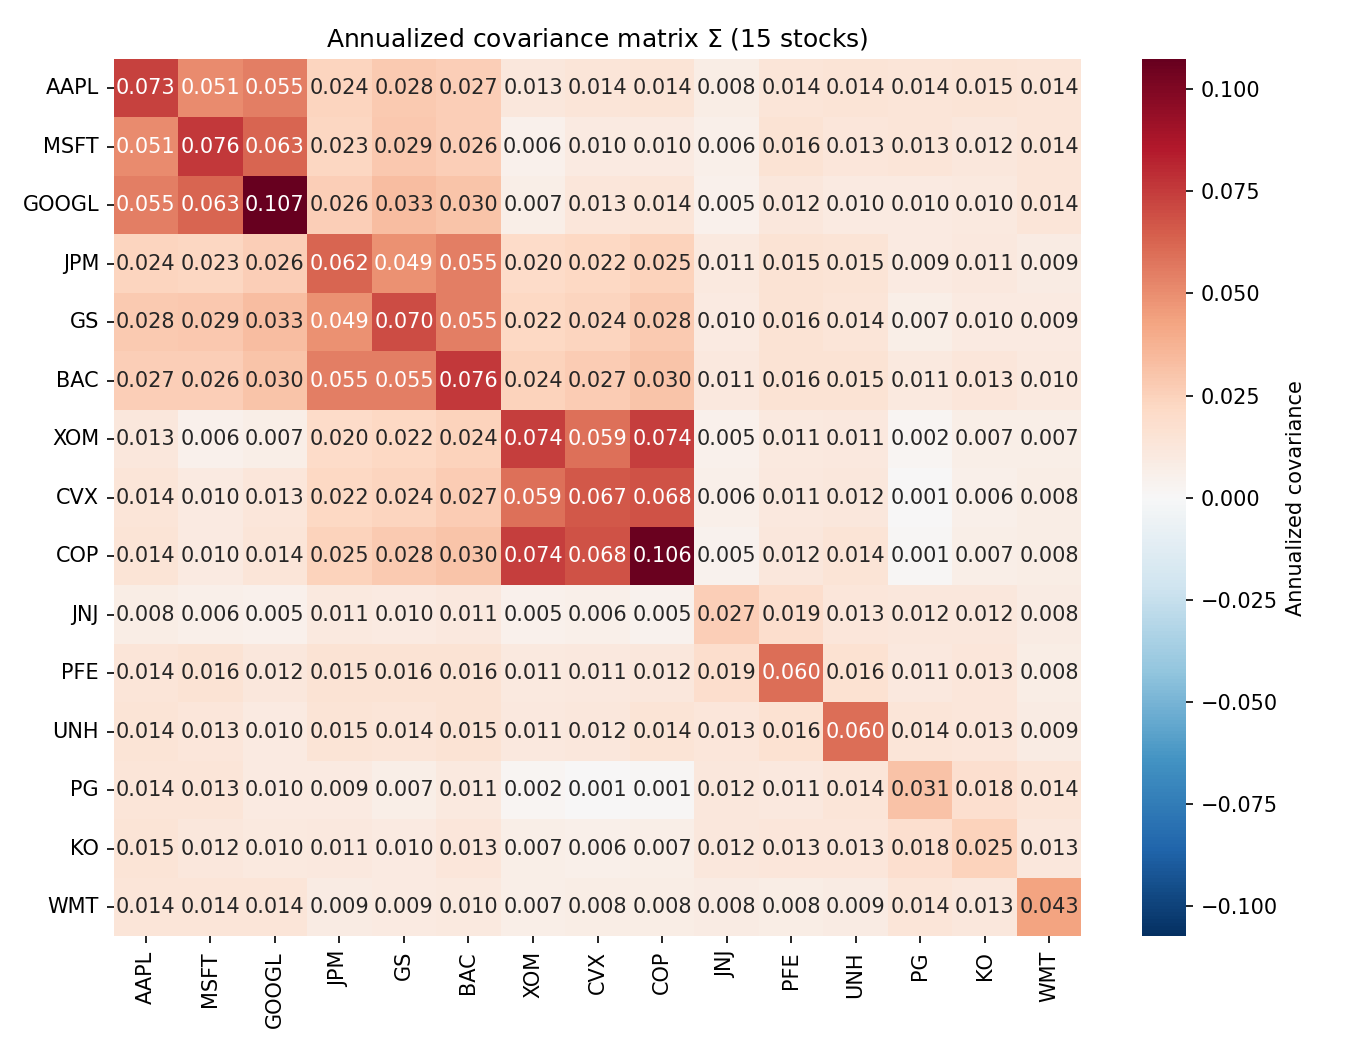

In [5]:
import seaborn as sns
from IPython.display import Image

vmax = float(np.max(np.abs(sigma)))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    sigma,
    annot=True, fmt=".3f",
    cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
    xticklabels=TICKERS, yticklabels=TICKERS,
    cbar_kws={"label": "Annualized covariance"},
    ax=ax,
)
ax.set_title("Annualized covariance matrix $\\Sigma$ (15 stocks)")
plt.tight_layout()
fig.savefig("covariance_heatmap.png", dpi=150)
plt.close(fig)
Image("covariance_heatmap.png")

The correlation matrix $\rho$ is the most informative single object —
it controls the clustering downstream. Plot it as a heatmap.


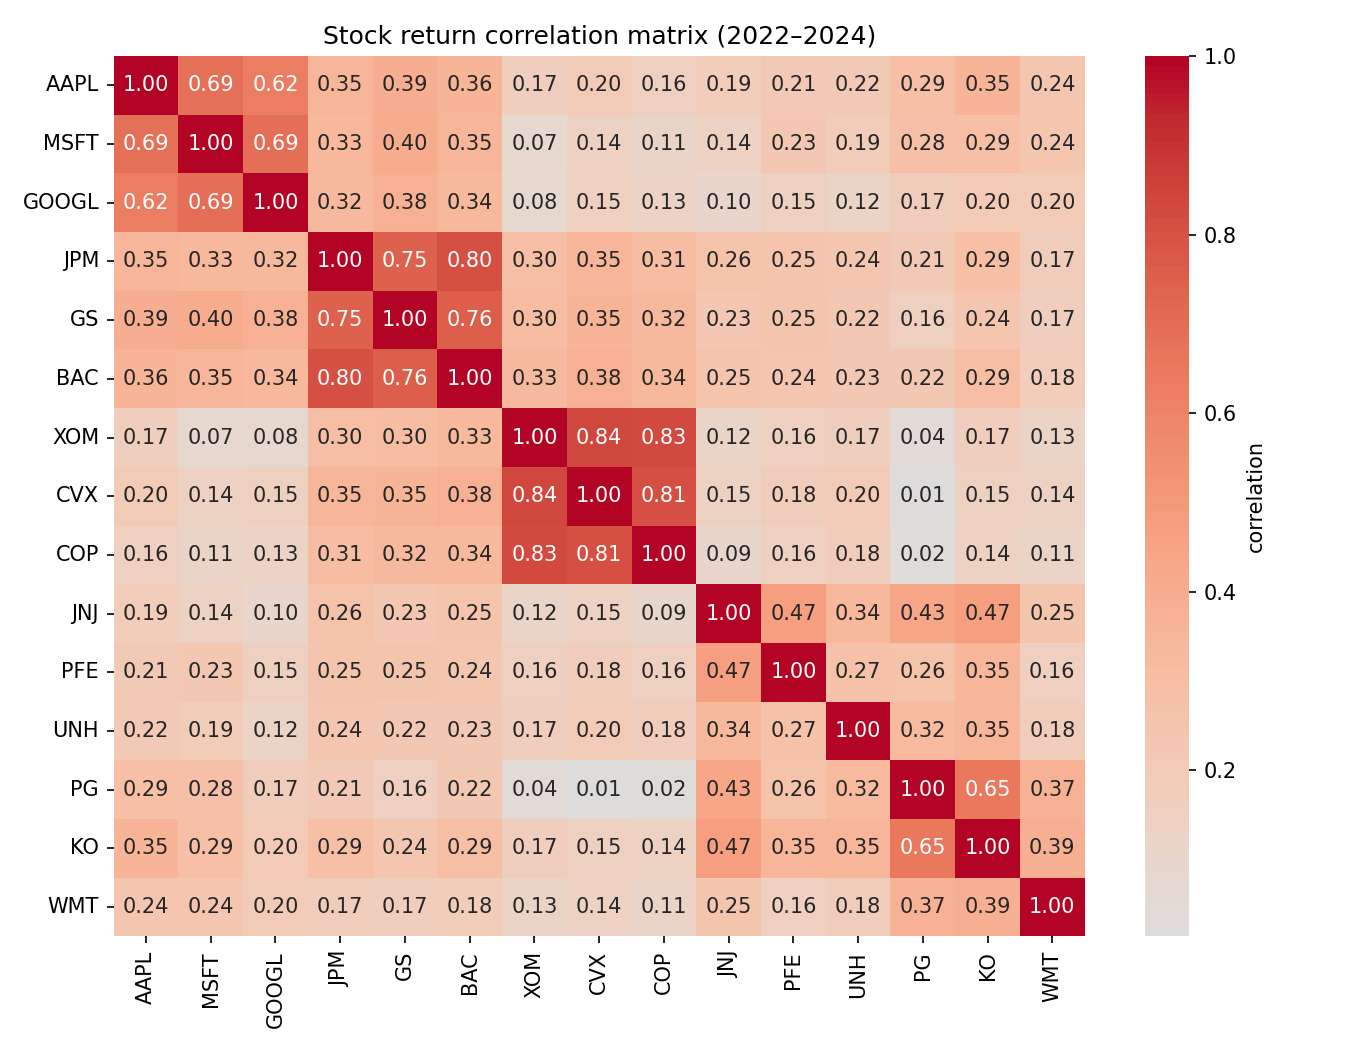

In [6]:
import seaborn as sns
from IPython.display import Image

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(rho, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=TICKERS, yticklabels=TICKERS, ax=ax,
            cbar_kws={"label": "correlation"})
ax.set_title("Stock return correlation matrix (2022–2024)")
plt.tight_layout()
fig.savefig("correlation_heatmap.png", dpi=150)
plt.close(fig)
Image("correlation_heatmap.png")

### Reading the heatmap

Look for the dark red blocks along the diagonal — those are sectors:

- **Energy** (XOM, CVX, COP): correlations around $0.83$ — they all move
  with oil prices.
- **Finance** (JPM, GS, BAC): around $0.77$ — they all move with rates
  and credit.
- **Tech** (AAPL, MSFT, GOOGL): around $0.67$ — looser block, since these
  are also exposed to broader market beta.

This block structure is the entire reason clustering will work. If every
stock were equally correlated with every other, splitting them into groups
would lose nearly all the information.


## 4. QUBO Formulation

A quantum optimisation device doesn't understand "minimise $f(x)$ subject
to $g(x) = 0$". It finds the ground state of a Hamiltonian. So we have
two jobs:

1. Fold the **budget constraint** into the objective as a penalty term.
2. Write the result as $x^\top Q x$ for some matrix $Q$ — the
   **QUBO** form.

### Step 1: penalising the constraint

We want $\sum_i x_i = B$. Define a penalty:

$$
P(x) \;=\; \lambda \left( \sum_i x_i - B \right)^2.
$$

If exactly $B$ stocks are selected, $P(x) = 0$. Otherwise $P(x) > 0$.
Pick $\lambda$ large enough that breaking the constraint is always worse
than any feasible portfolio.

Expanding:

$$
\left(\sum_i x_i - B\right)^2 \;=\; \sum_i x_i^2 + 2 \sum_{i < j} x_i x_j - 2 B \sum_i x_i + B^2.
$$

Since $x_i \in \{0,1\}$ implies $x_i^2 = x_i$, this simplifies to

$$
P(x) \;=\; \lambda \left[ (1 - 2B) \sum_i x_i + 2 \sum_{i<j} x_i x_j + B^2 \right].
$$

The constant $\lambda B^2$ doesn't affect the argmin — it ends up in an
*offset*.

### Step 2: combining into a single matrix Q

Adding the Markowitz objective $-\mu^\top x + q\, x^\top \Sigma x$ to the
penalty and collecting $x_i x_j$ terms:

$$
\boxed{ \quad
Q_{ii}    = -\mu_i + q\,\Sigma_{ii} + \lambda(1 - 2B), \qquad
Q_{ij}    = q\,\Sigma_{ij} + \lambda \;\;\;(i \ne j).
\quad}
$$

Then $\text{cost}(x) = x^\top Q x + \text{const}$, and we minimise
$x^\top Q x$ over $\{0,1\}^N$.

Reference: **[2]** Buonaiuto et al. (2023), eq. 7–11.

Now build $Q$ for the 15-stock universe. We use $B = 6$, $q = 0.5$,
$\lambda = 10$ — the penalty is large enough to dominate any reasonable
Markowitz term so that infeasible portfolios get crushed.


In [7]:
from src.qubo import build_qubo, brute_force_qubo

BUDGET = 6
Q_RISK = 0.5
PENALTY = 10.0

Q = build_qubo(mu, sigma, q=Q_RISK, budget=BUDGET, penalty=PENALTY)
print(f"Q shape       : {Q.shape}")
print(f"Q symmetric   : {np.allclose(Q, Q.T)}")
print(f"Q diagonal Q_ii (first 5): {np.diag(Q)[:5]}")

# Full Qubo matrix
print(f"\n\nQ: \n\t{Q}")


Q shape       : (15, 15)
Q symmetric   : True
Q diagonal Q_ii (first 5): [-110.0783 -110.0505 -110.0404 -110.1287 -110.1171]


Q: 
	[[-110.0783   10.0256   10.0277   10.0119   10.0141   10.0134   10.0063
    10.007    10.0072   10.0041   10.007    10.0072   10.0069   10.0075
    10.0068]
 [  10.0256 -110.0505   10.0314   10.0114   10.0146   10.0132   10.0028
    10.0049   10.005    10.003    10.0078   10.0064   10.0067   10.0062
    10.0069]
 [  10.0277   10.0314 -110.0404   10.0132   10.0164   10.0152   10.0035
    10.0065   10.007    10.0027   10.0062   10.0049   10.005    10.0052
    10.0069]
 [  10.0119   10.0114   10.0132 -110.1287   10.0246   10.0276   10.0101
    10.0111   10.0124   10.0054   10.0076   10.0073   10.0047   10.0057
    10.0045]
 [  10.0141   10.0146   10.0164   10.0246 -110.1171   10.0275   10.011
    10.0121   10.0139   10.0049   10.0079   10.0071   10.0037   10.005
    10.0047]
 [  10.0134   10.0132   10.0152   10.0276   10.0275 -109.9717   10.0122
    10.0135  

Sanity-check the QUBO on a 4-stock toy problem. With only 4 binary
variables there are $2^4 = 16$ candidate portfolios — small enough to
brute-force every one and confirm the QUBO actually encodes the
optimisation we want.


In [8]:
toy_idx = [0, 5, 6, 11]   # AAPL, BAC, XOM, UNH (cross-sector picks)
toy_mu = mu[toy_idx]
toy_sigma = sigma[np.ix_(toy_idx, toy_idx)]
toy_tickers = [TICKERS[i] for i in toy_idx]

Q_toy = build_qubo(toy_mu, toy_sigma, q=Q_RISK, budget=2, penalty=10.0)
x_opt, val_opt = brute_force_qubo(Q_toy, budget=2)
print(f"Toy universe: {toy_tickers}, budget = 2")
print(f"Optimal x         : {x_opt.astype(int)}")
print(f"  → selects        : {[t for t,b in zip(toy_tickers, x_opt) if b==1]}")
print(f"QUBO objective    : {val_opt:.4f}")
print(f"Expected return   : {float(toy_mu @ x_opt):.4f}")
print(f"Variance          : {float(x_opt @ toy_sigma @ x_opt):.4f}")


Toy universe: ['AAPL', 'BAC', 'XOM', 'UNH'], budget = 2
Optimal x         : [1 0 1 0]
  → selects        : ['AAPL', 'XOM']
QUBO objective    : -40.2351
Expected return   : 0.3214
Variance          : 0.1726


## 5. From QUBO to Ising Hamiltonian

Quantum hardware works in terms of Pauli operators, which have eigenvalues
$\pm 1$, not $0$ and $1$. The dictionary between binary $x_i$ and spin
$z_i$ is

$$
x_i \;=\; \frac{1 - z_i}{2}.
$$

So $z_i = +1$ (the $|0\rangle$ state) means $x_i = 0$ (stock not held),
and $z_i = -1$ (the $|1\rangle$ state) means $x_i = 1$ (stock held).

Substituting into $x^\top Q x$ and collecting terms gives the **Ising
form**:

$$
H \;=\; \sum_{i < j} J_{ij}\, Z_i Z_j \;+\; \sum_i h_i\, Z_i \;+\; \text{offset},
$$

where

$$
J_{ij} = \tfrac{Q_{ij}}{4}, \qquad
h_i = -\tfrac{1}{2} Q_{ii} - \tfrac{1}{4} \sum_{j \ne i} Q_{ij}.
$$

The ground state of $H$ — its lowest-eigenvalue eigenstate — is the
computational-basis state corresponding to the optimal portfolio.

Reference: **[3]** Lucas (2014).


In [9]:
from src.qubo import qubo_to_ising, qubo_to_cudaq_hamiltonian

J, h, offset = qubo_to_ising(Q)
print(f"Number of Z_i Z_j coupling terms : {(J != 0).sum() // 2}")
print(f"Number of single-Z field terms   : {(h != 0).sum()}")
print(f"Energy offset (constant)         : {offset:.4f}")
print(f"\nh (single-qubit fields):\n{h}")


Number of Z_i Z_j coupling terms : 105
Number of single-Z field terms   : 15
Energy offset (constant)         : -299.8651

h (single-qubit fields):
[-15.0372 -15.0477 -15.0557 -15.0144 -15.0251 -15.1019 -14.9822 -15.0371
 -15.0392 -15.0555 -15.1678 -15.052  -15.0254 -15.0238 -14.9339]


The Ising data above is what we'll build a `cudaq.SpinOperator` from. That
operator is what `cudaq.observe()` evaluates against the quantum state to
get the cost expectation value driving the optimiser.


In [10]:
H_cudaq = qubo_to_cudaq_hamiltonian(Q)
print(f"cudaq SpinOperator built.")
print(f"  Number of terms: {H_cudaq.get_term_count()}")
print(f"\nFirst few terms:")
print(str(H_cudaq)[:400])


cudaq SpinOperator built.
  Number of terms: 121

First few terms:
(-299.865+0i) * I0 + (-15.0372+0i) * Z0 + (-15.0477+0i) * Z1 + (-15.0557+0i) * Z2 + (-15.0144+0i) * Z3 + (-15.0251+0i) * Z4 + (-15.1019+0i) * Z5 + (-14.9822+0i) * Z6 + (-15.0371+0i) * Z7 + (-15.0392+0i) * Z8 + (-15.0555+0i) * Z9 + (-15.1678+0i) * Z10 + (-15.052+0i) * Z11 + (-15.0254+0i) * Z12 + (-15.0238+0i) * Z13 + (-14.9339+0i) * Z14 + (5.01279+0i) * Z0Z1 + (5.01383+0i) * Z0Z2 + (5.00594+0i) * Z


/tmp/ipykernel_3607817/3990337839.py:3: DeprecationWarning: use `term_count` instead
  print(f"  Number of terms: {H_cudaq.get_term_count()}")


## 6. Stock Clustering — Splitting the Problem

A 15-qubit problem is fine on a single QPU, but 100 or 500 qubits is not.
The **divide-and-conquer** trick: cluster correlated stocks together,
solve each cluster independently on its own QPU, then merge.

The per-cluster QUBO drops the cross-cluster $\Sigma_{ij}$ entries — that
information is "lost" until the merge step recovers it via local search.
The smarter the clustering, the less information is lost.

### The distance formula

Correlation $\rho \in [-1, 1]$ is a similarity, not a distance. Convert
it via

$$
d_{ij} \;=\; \sqrt{2 (1 - \rho_{ij})}.
$$

This is a **proper metric** (it satisfies the triangle inequality), which
Ward's algorithm requires. Geometrically: if you treat each stock's
return series as a unit vector with dot product $\rho_{ij}$, then $d_{ij}$
is the Euclidean distance between the two unit vectors. So perfectly
correlated stocks ($\rho = 1$) are at distance $0$; uncorrelated stocks
($\rho = 0$) are at $\sqrt{2}$; perfectly anti-correlated stocks
($\rho = -1$) are at $2$.

Reference: **[6]** López de Prado (2016).

### Ward linkage

We use **agglomerative hierarchical clustering**: start with each stock
as its own cluster, then repeatedly merge the two clusters whose merger
increases total within-cluster variance the least. Cut the resulting tree
at $k = 4$ to get four clusters — one per QPU.


In [11]:
from src.clustering import (
    cluster_stocks, build_subproblems, plot_dendrogram,
    plot_clustered_heatmap, compute_cross_cluster_loss,
)

N_CLUSTERS = 4
labels = cluster_stocks(rho, n_clusters=N_CLUSTERS)
print("Cluster assignment:")
for c in range(N_CLUSTERS):
    members = [TICKERS[i] for i in range(len(TICKERS)) if labels[i] == c]
    print(f"  Cluster {c}: {members}")


Cluster assignment:
  Cluster 0: ['XOM', 'CVX', 'COP']
  Cluster 1: ['JNJ', 'PFE', 'UNH', 'PG', 'KO', 'WMT']
  Cluster 2: ['JPM', 'GS', 'BAC']
  Cluster 3: ['AAPL', 'MSFT', 'GOOGL']


Visualise the merge order with a **dendrogram**. Vertical position of
each merge represents the Ward-linkage distance — the lower the merge,
the more similar the two sub-clusters being joined.


Dendrogram saved to dendrogram.png


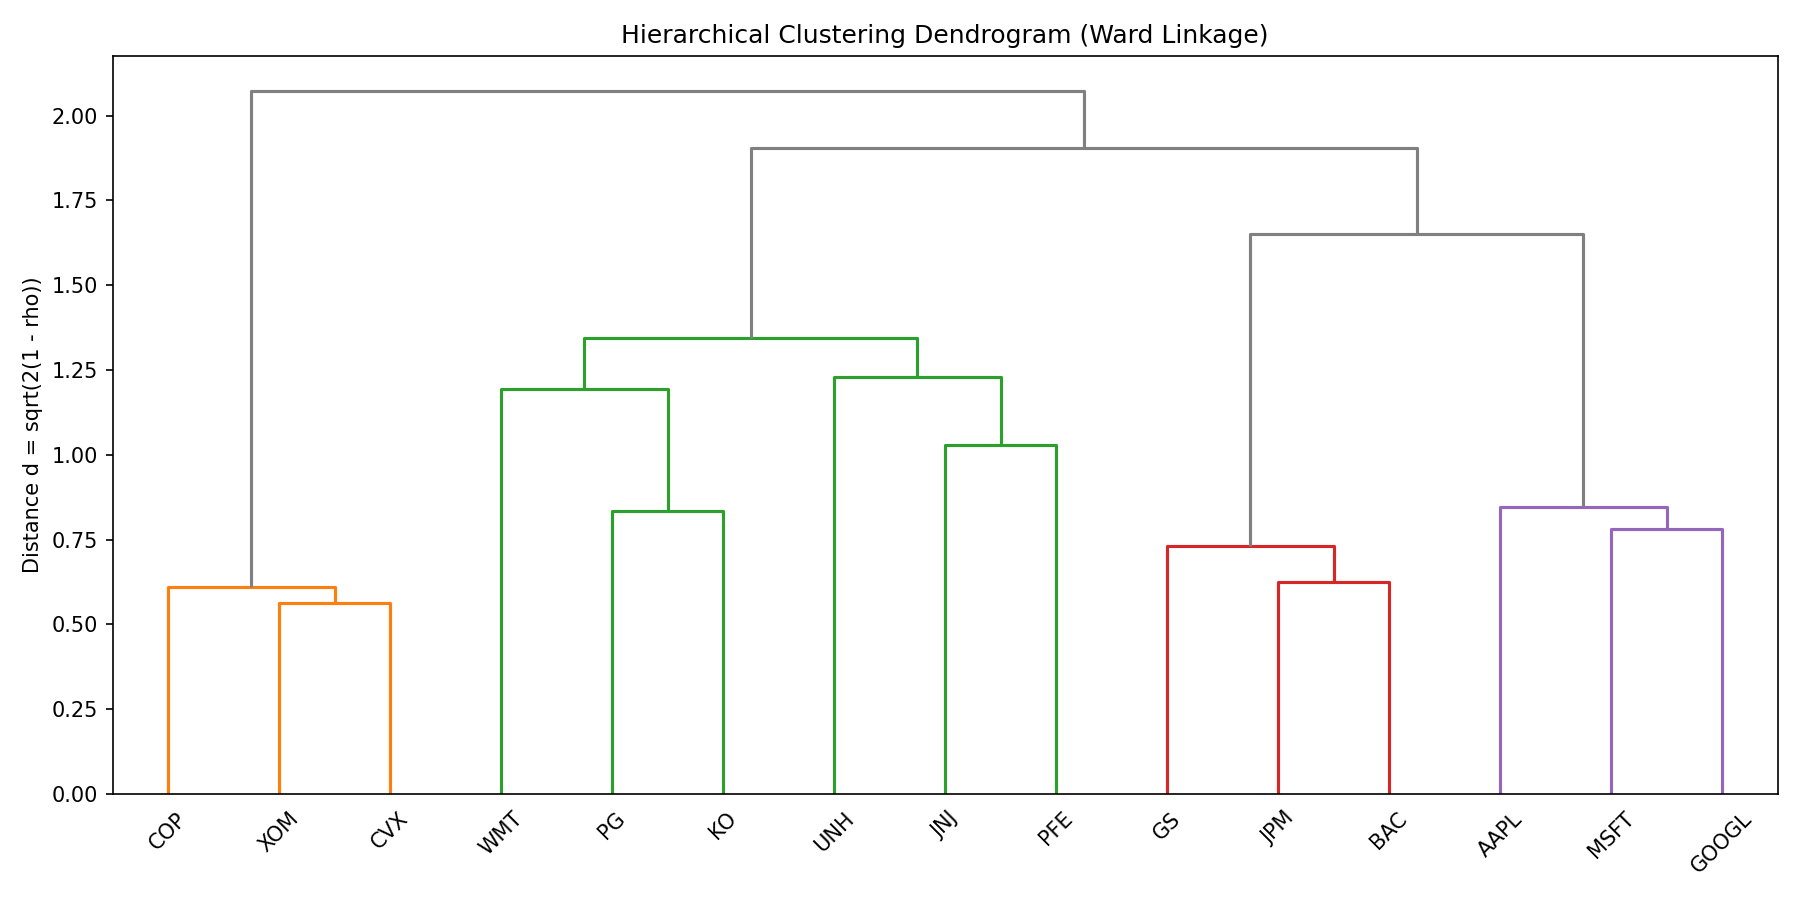

In [12]:
plot_dendrogram(rho, TICKERS, save_path="dendrogram.png", n_clusters=N_CLUSTERS)
from IPython.display import Image
Image("dendrogram.png")


The same data can be visualised by reordering the correlation heatmap so
that members of each cluster are adjacent. Good clusters appear as bright
diagonal blocks separated by dim off-diagonal regions.


Clustered heatmap saved to clustered_heatmap.png


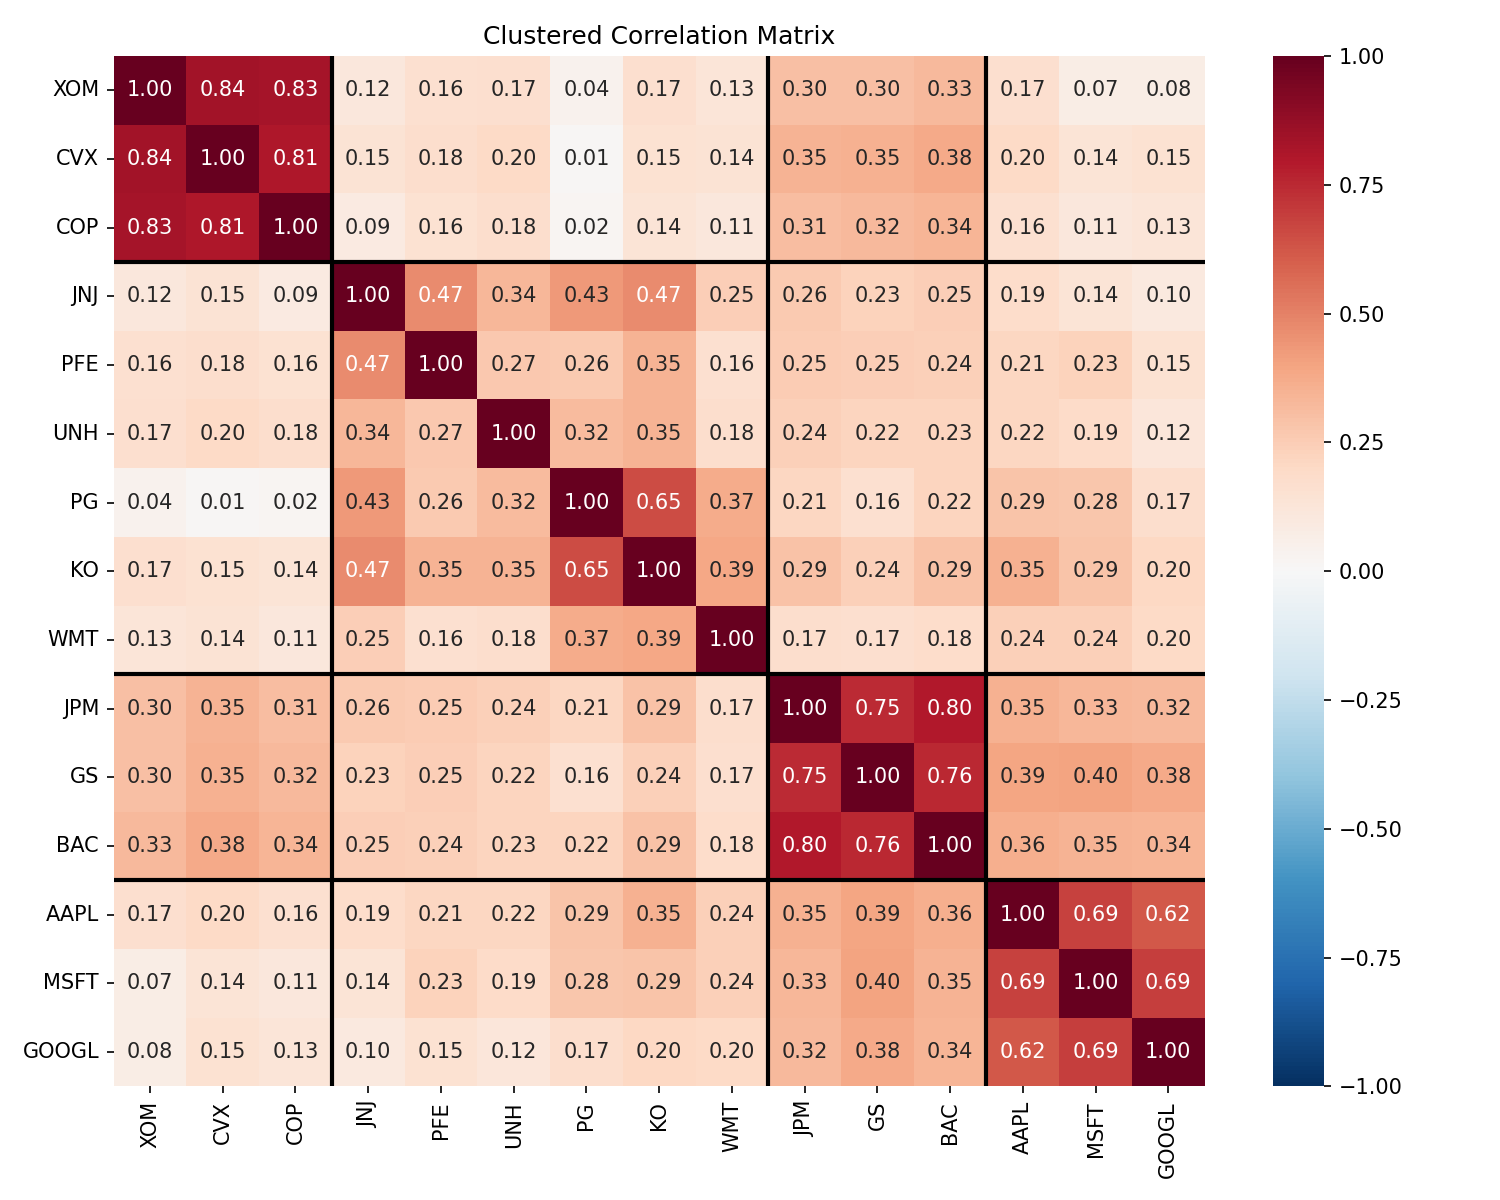

In [13]:
plot_clustered_heatmap(rho, labels, TICKERS, save_path="clustered_heatmap.png")
Image("clustered_heatmap.png")


### Sub-budget allocation

Total budget is $B = 6$, but our 4 clusters have unequal sizes. Each
cluster gets a sub-budget proportional to its size, but **integer**.
That's not generally possible exactly, so we use the **largest-remainder
(Hamilton) method** — the same method used in political seat
apportionment:

1. Compute the ideal proportional allocation: $b_c^\star = B \cdot |C_c| / N$.
2. Floor each: $b_c = \lfloor b_c^\star \rfloor$.
3. Distribute the remaining seats $B - \sum_c b_c$ to the clusters with
   the largest fractional remainders.

`build_subproblems` does this and packages each cluster as a
self-contained mini-QUBO problem, complete with its sub-budget, local
$\mu$, local $\Sigma$, and the Ising terms ready for CUDA-Q.


In [14]:
subproblems = build_subproblems(
    mu, sigma, labels,
    budget=BUDGET, q=Q_RISK, penalty=PENALTY, tickers=TICKERS,
)

for sp in subproblems:
    print(f"  Cluster {sp['cluster_id']:>1d} ({len(sp['stock_indices'])} stocks): "
          f"{sp['tickers']}, sub-budget = {sp['budget']}")


  Cluster 0 (3 stocks): ['XOM', 'CVX', 'COP'], sub-budget = 1
  Cluster 1 (6 stocks): ['JNJ', 'PFE', 'UNH', 'PG', 'KO', 'WMT'], sub-budget = 3
  Cluster 2 (3 stocks): ['JPM', 'GS', 'BAC'], sub-budget = 1
  Cluster 3 (3 stocks): ['AAPL', 'MSFT', 'GOOGL'], sub-budget = 1


### Cross-cluster covariance loss

How much of the original problem are we throwing away by treating
clusters independently?

We compare the sum of squared covariances *between* clusters to the total
sum of squared covariances. That ratio is the fraction of "covariance
mass" our distributed solver is blind to. The local-search pass at the
end of the pipeline is what we use to recover it.


In [15]:
loss = compute_cross_cluster_loss(sigma, labels)
print(f"Cross-cluster covariance loss: {loss * 100:.1f}%")


Cross-cluster covariance loss: 61.0%


A loss in the $50$–$70\%$ range is high but normal for broadly correlated
equity markets where every stock shares "market beta". The merge +
local-search step in Section 9 recovers a meaningful fraction of it
without any extra quantum work.

Sources for the divide-and-conquer pattern: **[7]** NVIDIA cuda-q-academic
tutorials, **[9]** IonQ distributed portfolio optimization (2026).


### What does the cross-cluster loss actually measure?

When we split the 15 stocks into 4 clusters and solve each independently,
**every cluster's QAOA sees only the covariance entries inside its own block**.
The energy cluster's QPU has no idea that XOM (energy) correlates with JPM
(financials) at $\rho \approx 0.30$, because that pair simply doesn't appear in
its sub-problem.

Cross-cluster loss measures, of all the pairwise covariance information in the
full $15 \times 15\;\Sigma$ matrix, what fraction lives **between** clusters
(and therefore gets ignored):

$$
\text{Loss} \;=\;
\frac{\displaystyle\sum_{\substack{i \neq j \\ \text{labels}[i] \neq \text{labels}[j]}}
        \bigl|\Sigma_{ij}\bigr|}
     {\displaystyle\sum_{i \neq j}\bigl|\Sigma_{ij}\bigr|}.
$$

We use **absolute values** because negative covariance — pairs that move in
opposite directions — is just as valuable for risk control as positive
covariance. Throwing away $\Sigma_{ij} = -0.05$ is just as much a loss as
throwing away $\Sigma_{ij} = +0.05$.

**Why is the number so high (~ 60 %)?** With 4 clusters of sizes
$(3, 6, 3, 3)$ there are
$\binom{3}{2} + \binom{6}{2} + \binom{3}{2} + \binom{3}{2} = 3 + 15 + 3 + 3 = 24$
within-cluster pairs out of $\binom{15}{2} = 105$ total — so $81 / 105 \approx
77\%$ of all pairs are cross-cluster by count alone. Within-cluster pairs do
have *individually* larger covariances on average (that's exactly why
clustering grouped them together), but $77\%$ of the pairs is enough that the
cross-cluster contributions still dominate the *sum* of $|\Sigma_{ij}|$.

This is the **fundamental tradeoff of distributed quantum optimisation**: more
QPUs $\Rightarrow$ more parallelism $\Rightarrow$ smaller per-cluster
sub-problems $\Rightarrow$ more cross-cluster covariance ignored. The whole
point of the local-search post-processing step in Section 9 is to recover this
lost information by evaluating the merged portfolio against the **full**
$\Sigma$ and accepting any swap that improves the *global* objective.

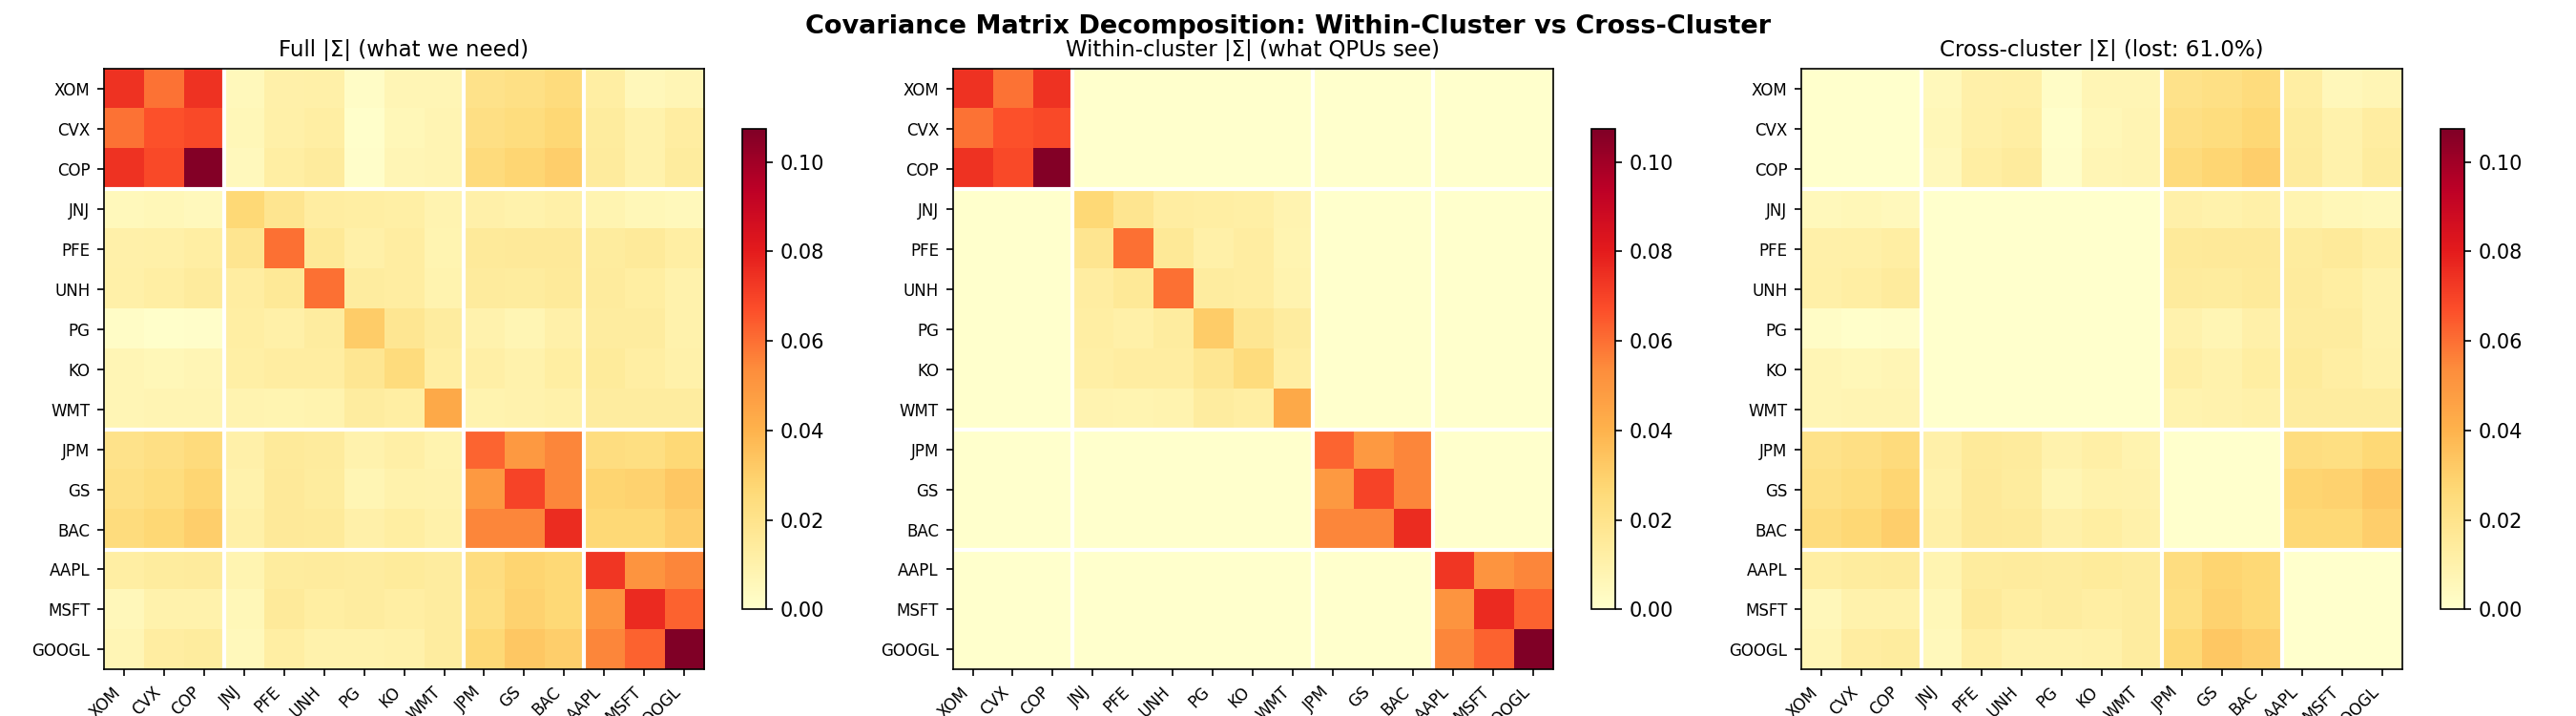

In [16]:
from IPython.display import Image

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reorder rows/columns so cluster members are contiguous (clean block structure)
order = np.argsort(labels, kind="stable")
sigma_ordered = sigma[np.ix_(order, order)]
labels_ordered = labels[order]
tickers_ordered = [TICKERS[i] for i in order]
vmax_full = float(np.abs(sigma_ordered).max())

# Helper to draw cluster boundary lines on a heatmap
def _draw_boundaries(ax):
    pos = 0
    for lbl in np.unique(labels_ordered)[:-1]:
        pos += int(np.sum(labels_ordered == lbl))
        ax.axhline(y=pos - 0.5, color="white", linewidth=2)
        ax.axvline(x=pos - 0.5, color="white", linewidth=2)

# 1. Full covariance |Σ|
ax = axes[0]
im = ax.imshow(np.abs(sigma_ordered), cmap="YlOrRd", aspect="equal",
               vmin=0, vmax=vmax_full)
ax.set_xticks(range(len(tickers_ordered)))
ax.set_xticklabels(tickers_ordered, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(tickers_ordered)))
ax.set_yticklabels(tickers_ordered, fontsize=8)
ax.set_title("Full |Σ| (what we need)", fontsize=11)
_draw_boundaries(ax)
plt.colorbar(im, ax=ax, shrink=0.8)

# 2. Within-cluster only (what each QPU sees)
within_mask = np.where(
    labels_ordered[:, None] == labels_ordered[None, :],
    np.abs(sigma_ordered), 0.0,
)
ax = axes[1]
im = ax.imshow(within_mask, cmap="YlOrRd", aspect="equal",
               vmin=0, vmax=vmax_full)
ax.set_xticks(range(len(tickers_ordered)))
ax.set_xticklabels(tickers_ordered, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(tickers_ordered)))
ax.set_yticklabels(tickers_ordered, fontsize=8)
ax.set_title("Within-cluster |Σ| (what QPUs see)", fontsize=11)
_draw_boundaries(ax)
plt.colorbar(im, ax=ax, shrink=0.8)

# 3. Cross-cluster only (what gets lost)
cross_mask = np.where(
    labels_ordered[:, None] != labels_ordered[None, :],
    np.abs(sigma_ordered), 0.0,
)
ax = axes[2]
im = ax.imshow(cross_mask, cmap="YlOrRd", aspect="equal",
               vmin=0, vmax=vmax_full)
ax.set_xticks(range(len(tickers_ordered)))
ax.set_xticklabels(tickers_ordered, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(tickers_ordered)))
ax.set_yticklabels(tickers_ordered, fontsize=8)
ax.set_title(f"Cross-cluster |Σ| (lost: {loss*100:.1f}%)", fontsize=11)
_draw_boundaries(ax)
plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(
    "Covariance Matrix Decomposition: Within-Cluster vs Cross-Cluster",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
fig.savefig("cross_cluster_decomposition.png", dpi=150)
plt.close(fig)
Image("cross_cluster_decomposition.png")

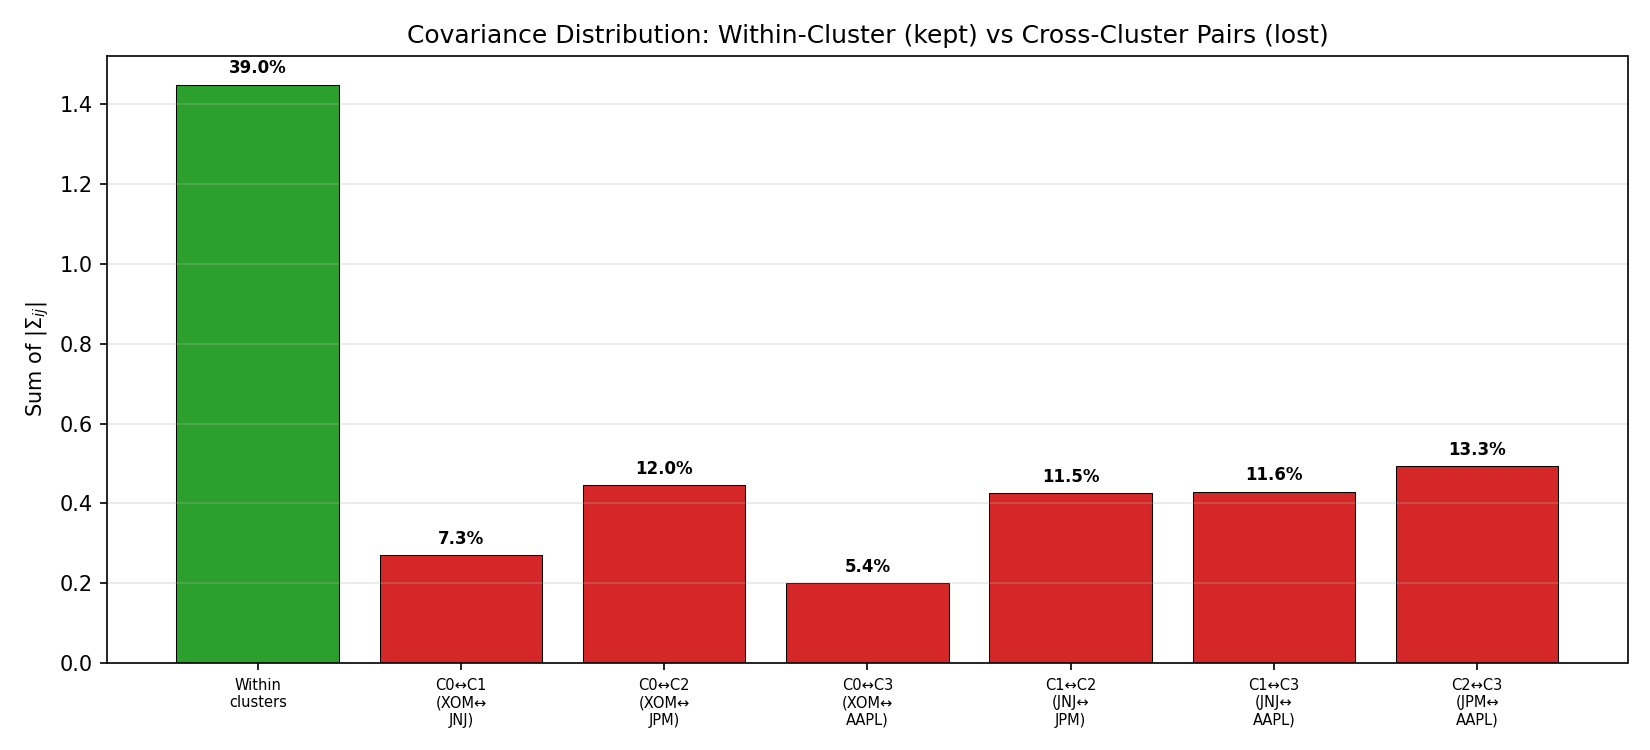

In [17]:
from IPython.display import Image

unique_labels = np.unique(labels)
cluster_names = {}
for k in unique_labels:
    members = [TICKERS[i] for i in range(len(TICKERS)) if labels[i] == k]
    # Truncate long lists for the legend
    cluster_names[k] = ", ".join(members[:2]) + ("..." if len(members) > 2 else "")

# Aggregate within-cluster total and per-pair cross-cluster totals
within_total = 0.0
cross_by_pair = {}
for i in range(len(labels)):
    for j in range(len(labels)):
        if i == j:
            continue
        val = abs(float(sigma[i, j]))
        if labels[i] == labels[j]:
            within_total += val
        else:
            pair = tuple(sorted((int(labels[i]), int(labels[j]))))
            cross_by_pair[pair] = cross_by_pair.get(pair, 0.0) + val

bar_labels = ["Within\nclusters"]
bar_values = [within_total]
bar_colors = ["#2ca02c"]
for pair in sorted(cross_by_pair.keys()):
    c1, c2 = pair
    name1 = cluster_names[c1].split(",")[0]
    name2 = cluster_names[c2].split(",")[0]
    bar_labels.append(f"C{c1}↔C{c2}\n({name1}↔\n{name2})")
    bar_values.append(cross_by_pair[pair])
    bar_colors.append("#d62728")

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(bar_labels, bar_values, color=bar_colors,
              edgecolor="black", linewidth=0.5)
ax.set_ylabel(r"Sum of $|\Sigma_{ij}|$")
ax.set_title("Covariance Distribution: Within-Cluster (kept) vs Cross-Cluster Pairs (lost)")
ax.grid(True, axis="y", alpha=0.3)

# Percentage of total above each bar
total_all = sum(bar_values)
for bar, val in zip(bars, bar_values):
    pct = val / total_all * 100 if total_all > 0 else 0.0
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_all * 0.005,
            f"{pct:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")

plt.xticks(fontsize=7)
plt.tight_layout()
fig.savefig("cross_cluster_bar.png", dpi=150)
plt.close(fig)
Image("cross_cluster_bar.png")

### Reading the three panels

- **Left — full $|\Sigma|$.** The complete pairwise covariance matrix, ordered
  so that cluster members sit next to each other. White boundary lines mark
  cluster blocks. This is what a single-QPU solve of the 15-qubit problem
  would have access to.
- **Middle — within-cluster only.** Zero everywhere outside the diagonal
  blocks. **This is the union of what our 4 QPUs collectively see** during
  per-cluster QAOA. The dark blocks along the diagonal are exactly the
  within-cluster covariance entries (strong, because the clustering algorithm
  *chose* to group these stocks together).
- **Right — cross-cluster only.** The off-diagonal blocks — every pair of
  stocks in *different* clusters. These are the entries each QPU is blind to.
  They aren't zero: there is real, non-trivial covariance between clusters
  that the distributed solver throws away.

### Reading the bar chart

The bar chart breaks down the distributed solver's view of the covariance
into one "kept" bucket (the green within-cluster total) and one bar per
cluster pair (red, lost). Cluster pairs that share moderate correlations —
e.g. financials ↔ tech, or energy ↔ consumer staples — produce the largest
red bars: lots of stock pairs, each contributing a moderate $|\Sigma_{ij}|$.

### Why this matters in the pipeline

This is exactly why the **local-search step** in Section 9 isn't an
afterthought. Per-cluster QAOA optimises each block in isolation; local
search then evaluates the merged portfolio against the **full** $\Sigma$
matrix and accepts any swap-one-in/swap-one-out move that improves the
*global* QUBO objective. In our run, that single classical pass took the
approximation ratio from $0.998$ (merged, partially blind) to $1.000$
(post-local-search, matches brute force) — recovering essentially all of the
information distributed dispatch had to ignore.

## 7. QAOA — The Quantum Algorithm

### Intuition first, no jargon

1. Put all $2^n$ portfolios in **uniform superposition** — every possible
   selection is a candidate at once.
2. Apply a parameterised gate sequence that **stamps the energy** of each
   portfolio onto its quantum phase, then **interferes** the candidates
   so that low-energy states accumulate amplitude and high-energy states
   cancel.
3. **Measure**. Sample many times. The most common bitstring is (with
   high probability) a low-energy portfolio.

The trick: the parameterised gates have free parameters $(\gamma, \beta)$
that we tune with a **classical optimiser** to maximise the chance of
landing on a good portfolio.

### The circuit, layer by layer

Let $H_C$ be the cost Hamiltonian (the Ising form from Section 5) and
$H_M = \sum_i X_i$ be the **mixer**. For depth $p$, the circuit applies

$$
|\psi(\gamma, \beta)\rangle
\;=\;
\underbrace{e^{-i \beta_p H_M}\, e^{-i \gamma_p H_C}}_{\text{layer }p}
\cdots
\underbrace{e^{-i \beta_1 H_M}\, e^{-i \gamma_1 H_C}}_{\text{layer }1}
\, H^{\otimes n} |0\rangle^{\otimes n}.
$$

In gate primitives:

- **Initial state.** $H^{\otimes n}|0\rangle^{\otimes n}$ — Hadamards
  produce the uniform superposition over all $2^n$ portfolios.
- **Problem unitary $e^{-i \gamma H_C}$.** For each $J_{ij} Z_i Z_j$
  term we use the standard *CNOT — Rz($2\gamma J_{ij}$) — CNOT*
  decomposition. For each $h_i Z_i$ term we apply Rz($2\gamma h_i$) on
  qubit $i$.
- **Mixer $e^{-i \beta H_M}$.** Rx($2\beta$) on every qubit.

Total parameter count is $2p$ — a small number, even for many qubits.
That's what makes QAOA tractable for classical optimisation.

### The classical loop

Inner loop (per QAOA evaluation):
1. Pick parameters $(\gamma, \beta) \in \mathbb{R}^{2p}$.
2. Build and run the circuit; estimate
   $\langle \psi(\gamma, \beta) | H_C | \psi(\gamma, \beta) \rangle$
   via `cudaq.observe()`.

Outer loop (parameter optimisation):
- Use **COBYLA** (Constrained Optimization BY Linear Approximations) to
  minimise the expectation. COBYLA is gradient-free, builds a local
  linear model from a simplex of recent evaluations, and updates it
  trust-region-style.

Why COBYLA? It's the standard first choice for QAOA because:

- The energy landscape has many flat regions and barren plateaus where
  numerical gradients are unreliable.
- It has very few hyperparameters and converges in tens of iterations
  for small $p$.
- It's what **[2]** Buonaiuto et al. (2023), the NVIDIA CUDA-Q QAOA
  tutorials, and Qiskit's tutorials all use as their default.

References: **[5]** Powell (1994), **[4]** Farhi, Goldstone & Gutmann
(2014).

Run QAOA at depths $p = 1, 2, 3$ on the smallest cluster — small enough
to compare against an exact brute-force solution.


In [18]:
from src.qaoa_cold import run_qaoa, evaluate_portfolio

small_sp = min(subproblems, key=lambda s: s["qubo"].shape[0])
print(f"Running QAOA on cluster {small_sp['cluster_id']}: "
      f"{small_sp['tickers']}, sub-budget = {small_sp['budget']}\n")

results_by_p = {}
for p in [1, 2, 3]:
    res = run_qaoa(
        small_sp["qubo"], small_sp["qubit_count"],
        layer_count=p, seed=42, shots=10000, maxiter=200,
    )
    results_by_p[p] = res
    print(f"  p={p}: best bitstring = {res['best_bitstring']}, "
          f"energy = {res['optimal_energy']:.4f}")


Running QAOA on cluster 0: ['XOM', 'CVX', 'COP'], sub-budget = 1



  p=1: best bitstring = 100, energy = -4.9045


  p=2: best bitstring = 110, energy = -3.6765


  p=3: best bitstring = 001, energy = -9.0440


The convergence trace shows COBYLA's running cost expectation as it
adjusts $(\gamma, \beta)$ at each depth. Deeper circuits have more
parameters and more expressive states, but also a harder optimisation
landscape.


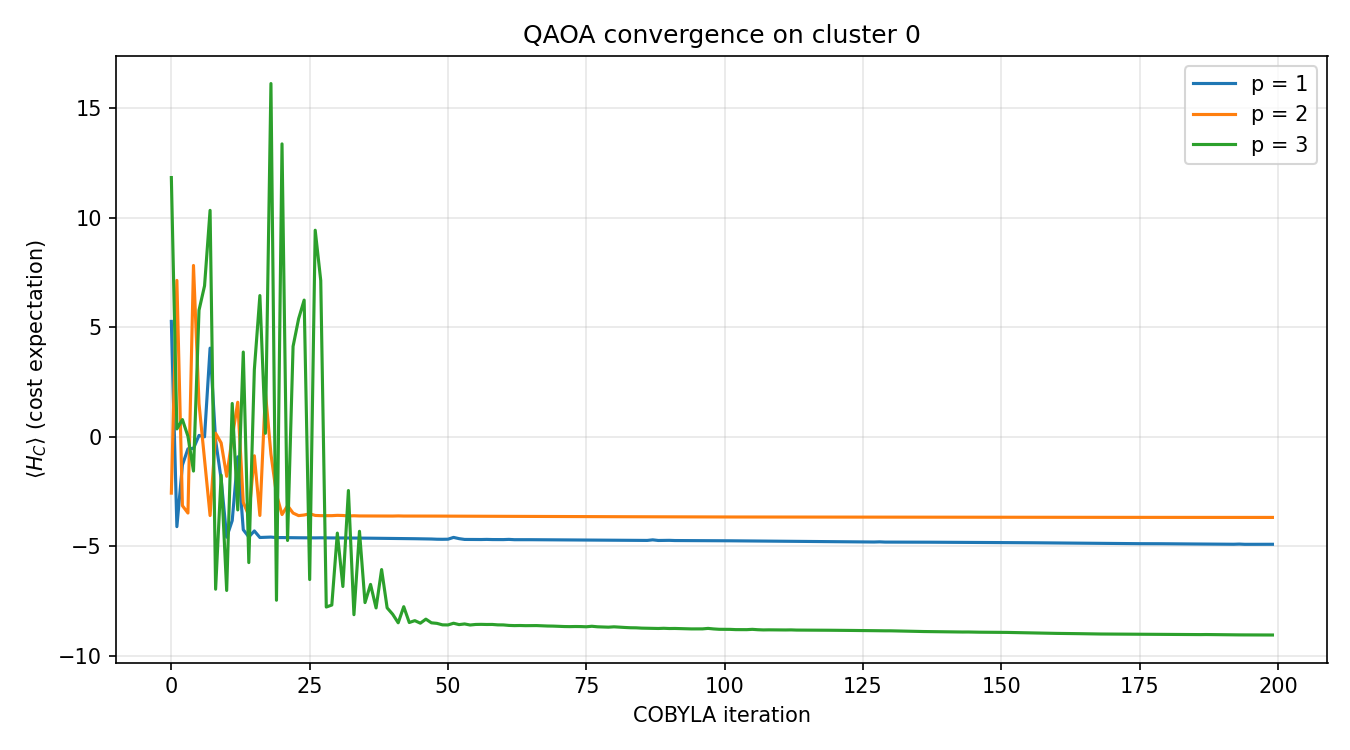

In [19]:
from IPython.display import Image

fig, ax = plt.subplots(figsize=(9, 5))
for p, res in results_by_p.items():
    if "convergence" in res and len(res["convergence"]) > 0:
        ax.plot(res["convergence"], label=f"p = {p}")
ax.set_xlabel("COBYLA iteration")
ax.set_ylabel(r"$\langle H_C \rangle$ (cost expectation)")
ax.set_title(f"QAOA convergence on cluster {small_sp['cluster_id']}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("qaoa_convergence.png", dpi=150)
plt.close(fig)
Image("qaoa_convergence.png")

Compare each depth's QAOA solution to the exact brute-force optimum on
this cluster. The **approximation ratio (AR)** is the QAOA energy divided
by the brute-force optimum — values close to $1$ mean we've matched (or
nearly matched) the true minimum.


In [20]:
bf_x, bf_val = brute_force_qubo(small_sp["qubo"], budget=small_sp["budget"])
bf_bs = "".join(str(int(b)) for b in bf_x)
print(f"Brute-force optimum: x = {bf_bs}  (energy = {bf_val:.4f})")
print(f"Selected: {[small_sp['tickers'][i] for i, b in enumerate(bf_x) if b==1]}\n")

print(f"{'p':>3s} {'QAOA bitstring':>16s} {'QAOA energy':>14s} {'AR':>10s}")
for p, res in results_by_p.items():
    ar = bf_val / res['optimal_energy'] if res['optimal_energy'] != 0 else float("nan")
    print(f"{p:>3d} {res['best_bitstring']:>16s} {res['optimal_energy']:>14.4f} {ar:>10.4f}")


Brute-force optimum: x = 100  (energy = -10.1694)
Selected: ['XOM']

  p   QAOA bitstring    QAOA energy         AR
  1              100        -4.9045     2.0735
  2              110        -3.6765     2.7660
  3              001        -9.0440     1.1244


## 8. Distributed Execution Across Multiple QPUs

The point of clustering was so that the per-cluster QAOA runs can happen
**in parallel**.

```
sequential (1 QPU):    [Cluster 0]→[Cluster 1]→[Cluster 2]→[Cluster 3]
                        |--------------------------------------------|
                                          total time

distributed (4 QPUs):  [Cluster 0]   on QPU 0
                       [Cluster 1]   on QPU 1     all simultaneous
                       [Cluster 2]   on QPU 2
                       [Cluster 3]   on QPU 3
                        |-------|
                          ~ max time
```

### CUDA-Q MQPU backend

NVIDIA CUDA-Q exposes a *multi-processor platform* abstraction where each
visible GPU appears as a virtual QPU. The relevant API:

- `cudaq.set_target("nvidia", option="mqpu")` — switch to the multi-QPU
  backend; one virtual QPU per GPU.
- `cudaq.sample_async(kernel, ..., qpu_id=i)` — non-blocking dispatch to
  QPU `i`. Returns an `AsyncSampleResult` future.
- `cudaq.observe_async(kernel, hamiltonian, ..., qpu_id=i)` — same idea
  for expectation values.
- `future.get()` — block until the assigned QPU returns the result.

We use **round-robin scheduling**: cluster $c$ goes to QPU
$c \bmod n_{\text{QPUs}}$.

Reference: **[8]** NVIDIA CUDA-Q *Multi-Processor Platforms* documentation.

First, configure MQPU and report what we have available.


In [21]:
from src.distributed import setup_mqpu, run_distributed_cold_qaoa

info = setup_mqpu()
print(f"Backend     : {info['backend']}")
print(f"Num QPUs    : {info['num_qpus']}")
print(f"Note        : {info['note']}")


Backend     : mqpu
Num QPUs    : 4
Note        : NVIDIA MQPU backend active — parallel sampling across GPUs


Now dispatch the four cluster QAOAs across the available QPUs. With the
`nvidia,mqpu` backend each cluster runs on its own GPU; the function also
falls back to sequential execution on `qpp-cpu` or numpy if no GPUs are
visible.


In [22]:
distributed_results = run_distributed_cold_qaoa(
    subproblems, layer_count=2, seed=42, shots=10000, maxiter=200,
)
print(f"Got {len(distributed_results)} per-cluster results.")


Got 4 per-cluster results.


Per-cluster summary: which QPU handled which cluster, what bitstring the
sampling produced, and the energy of that bitstring under the cluster's
local QUBO.


In [23]:
print(f"{'Cluster':<8s} {'Tickers':<32s} {'Bitstring':<14s} "
      f"{'Sampled E':>12s} {'Optimal E':>12s} {'QPU':>4s} {'Time (s)':>10s}")
print("-" * 100)
for r in distributed_results:
    sp = next(s for s in subproblems if s["cluster_id"] == r["cluster_id"])
    tickers_str = ",".join(sp["tickers"])
    print(f"{r['cluster_id']:<8d} {tickers_str:<32s} {r['best_bitstring']:<14s} "
          f"{r['sampled_energy']:>12.4f} {r['optimal_energy']:>12.4f} "
          f"{r['qpu_id']:>4d} {r['timing_s']:>10.2f}")


Cluster  Tickers                          Bitstring         Sampled E    Optimal E  QPU   Time (s)
----------------------------------------------------------------------------------------------------
0        XOM,CVX,COP                      110                 -0.1770      -3.6765    0      10.40
1        JNJ,PFE,UNH,PG,KO,WMT            000111             -90.2111     -88.7947    1      10.86
2        JPM,GS,BAC                       100                -10.1287      -8.8063    2       6.72
3        AAPL,MSFT,GOOGL                  001                -10.0404      -5.3092    3      10.24


## 9. Merging and Post-Processing

### The index mapping problem

Each cluster gives us a **local** bitstring of length $|C_c|$ — the
selection within that cluster's own indexing. To get a single global
portfolio of length $N=15$ we have to map those local indices back to
their original positions in the universe.

Concretely, if cluster 0 contains stocks at global indices `[6, 7, 8]`
and the QAOA returned `"010"`, then globally we have $x_6 = 0$,
$x_7 = 1$, $x_8 = 0$. `merge_subportfolios` does exactly this rebinding.


In [24]:
from src.merge import merge_subportfolios, evaluate_full_portfolio, local_search

x_merged = merge_subportfolios(distributed_results, subproblems, n_total=len(TICKERS))
print(f"Merged binary vector x:\n  {x_merged.astype(int)}")
print(f"\nSelected stocks ({int(x_merged.sum())} chosen):")
for i, b in enumerate(x_merged):
    if b == 1:
        print(f"  {TICKERS[i]}")


Merged binary vector x:
  [0 0 1 1 0 0 1 1 0 0 0 0 1 1 1]

Selected stocks (7 chosen):
  GOOGL
  JPM
  XOM
  CVX
  PG
  KO
  WMT


Now evaluate the merged portfolio using the **full** $\mu$ and $\Sigma$
— including the cross-cluster covariance entries that the distributed
solve ignored. Expect risk to look worse here than the per-cluster
energies suggested, because those local energies didn't see cross-cluster
covariance.


In [25]:
port_merged = evaluate_full_portfolio(x_merged, mu, sigma, q=Q_RISK)

print("Merged portfolio (before local search):")
print(f"  Stocks selected : {[TICKERS[i] for i in port_merged['selected_indices']]}")
print(f"  n_selected      : {port_merged['n_selected']}  (target = {BUDGET})")
print(f"  Expected return : {port_merged['expected_return']:+.4f}")
print(f"  Risk (sigma)    : {port_merged['risk']:.4f}")
print(f"  Sharpe ratio    : {port_merged['sharpe_ratio']:.4f}")
print(f"  Markowitz obj   : {port_merged['markowitz_obj']:.4f}")


Merged portfolio (before local search):
  Stocks selected : ['GOOGL', 'JPM', 'XOM', 'CVX', 'PG', 'KO', 'WMT']
  n_selected      : 7  (target = 6)
  Expected return : +0.8651
  Risk (sigma)    : 0.9914
  Sharpe ratio    : 0.8273
  Markowitz obj   : -0.3737


### Local search

The merged portfolio ignored a large fraction of the covariance
structure (the cross-cluster percentage we computed in Section 6). A
cheap way to recover some of that is **greedy 1-swap local search** on
the *full* QUBO matrix:

1. Look at the currently selected stocks $S$ and unselected stocks
   $\bar S$.
2. For every pair $(i \in S,\, j \in \bar S)$ try swapping: remove
   $i$, add $j$. Compute $\Delta = (x')^\top Q x' - x^\top Q x$.
3. If any swap has $\Delta < 0$, take the *best* such swap and repeat.
   If no improving swap exists, stop.

This is **budget-preserving by construction** — we always remove one and
add one. And it always evaluates against the full $15 \times 15$ QUBO,
so it directly fights the cross-cluster information loss without any
extra quantum work.


In [26]:
Q_global = build_qubo(mu, sigma, q=Q_RISK, budget=BUDGET, penalty=PENALTY)
x_polished = local_search(x_merged, Q_global, budget=BUDGET, max_swaps=100)
n_swaps = int((x_polished != x_merged).sum() // 2)
print(f"Local search made {n_swaps} swap(s).")


Local search made 2 swap(s).


Evaluate the polished portfolio against the full covariance matrix and
compare numerically against the unpolished merge.


In [27]:
port_polished = evaluate_full_portfolio(x_polished, mu, sigma, q=Q_RISK)

print("After greedy local search:")
print(f"  Stocks selected : {[TICKERS[i] for i in port_polished['selected_indices']]}")
print(f"  n_selected      : {port_polished['n_selected']}  (target = {BUDGET})")
print(f"  Expected return : {port_polished['expected_return']:+.4f}")
print(f"  Risk (sigma)    : {port_polished['risk']:.4f}")
print(f"  Sharpe ratio    : {port_polished['sharpe_ratio']:.4f}")
print(f"  Markowitz obj   : {port_polished['markowitz_obj']:.4f}")


After greedy local search:
  Stocks selected : ['AAPL', 'JPM', 'GS', 'XOM', 'PG', 'KO', 'WMT']
  n_selected      : 7  (target = 6)
  Expected return : +0.9380
  Risk (sigma)    : 1.0039
  Sharpe ratio    : 0.8895
  Markowitz obj   : -0.4340


## 10. Classical Warm-Start: The Goemans–Williamson Algorithm

Cold-start QAOA begins from the uniform superposition $|+\rangle^{\otimes n}$ —
every $2^n$ portfolio is equally likely at the start. The classical optimiser
then has to discover good regions of the Hilbert space using only gradient
information from a noisy expectation value. **What if we gave it a hint?**

The Goemans–Williamson (GW) algorithm provides a fast, classical, *approximate*
solution to QUBO/Ising problems that we can feed into QAOA as a starting bias.

**The recipe:**

1. **Relax the binary problem to a continuous one (SDP relaxation).**
   Replace the rank-1 outer product $\mathbf{z}\mathbf{z}^\top$ (with
   $z_i \in \{-1,+1\}$) by a positive-semidefinite matrix $Y \succeq 0$ with
   unit diagonal. The relaxed program
   $$
   \min_{Y \succeq 0, \, Y_{ii}=1} \operatorname{tr}(W \cdot Y)
   $$
   is a **semidefinite program** and is solvable in polynomial time.

2. **Round back to binary by random hyperplanes.** Decompose $Y = V V^\top$,
   sample a uniformly random direction $\mathbf{r}$ on the unit sphere, and
   set $z_i = \operatorname{sign}(V_i \cdot \mathbf{r})$. Geometrically: every
   row of $V$ is a unit vector in $\mathbb{R}^n$; the hyperplane orthogonal to
   $\mathbf{r}$ partitions them into the $+1$ / $-1$ groups.

3. **Repeat the rounding many times** (we use $1000$ trials) and keep the best
   binary solution under the original objective.

For Max-Cut, GW famously achieves an approximation ratio of $\alpha_{GW}
\approx 0.878$ in expectation — meaning no purely-classical polynomial
algorithm is known to do better in the worst case (assuming the Unique Games
Conjecture).

### The auxiliary-spin trick for linear terms

Standard GW handles a quadratic Ising cost $\mathbf{z}^\top W \mathbf{z}$ with
no linear $h_i z_i$ term. Our portfolio Hamiltonian has both. The trick:
introduce a **dummy spin** $z_0$ pinned to $+1$ and rewrite each linear term
as a coupling: $h_i z_i = h_i \cdot z_0 \cdot z_i$. The extended SDP solves an
$(n{+}1)\times(n{+}1)$ problem, then we discard $z_0$ after rounding (flipping
the sign of all $z_i$ if rounding produced $z_0 = -1$).

**References.** Goemans & Williamson, *J. ACM* **42**, 1115 (1995);
implementation reference: <https://github.com/markolalovic/max-cut-sdp>.

In [28]:
from src.gw import gw_solve

# Run GW on the same small cluster we tested cold-start QAOA on
gw_x, gw_obj = gw_solve(
    small_sp["qubo"], budget=small_sp["budget"], num_trials=1000, seed=42
)
gw_bs = "".join(str(int(b)) for b in gw_x)
gw_port = evaluate_portfolio(gw_bs, small_sp["mu"], small_sp["sigma"], Q_RISK)

print(f"GW solution bitstring : {gw_bs}")
print(f"  Selected stocks      : {[small_sp['tickers'][i] for i in gw_port['selected_indices']]}")
print(f"  GW QUBO energy       : {gw_obj:.4f}")
print(f"  Brute-force optimum  : {bf_val:.4f}")
gw_ar = bf_val / gw_obj if abs(gw_obj) > 1e-10 and gw_obj < 0 else float("nan")
print(f"  Approximation ratio  : {gw_ar:.4f}")
print(f"  Return = {gw_port['expected_return']:.4f}, "
      f"Risk = {gw_port['risk']:.4f}, "
      f"Sharpe = {gw_port['sharpe_ratio']:.4f}")

GW solution bitstring : 100
  Selected stocks      : ['XOM']
  GW QUBO energy       : -10.1694
  Brute-force optimum  : -10.1694
  Approximation ratio  : 1.0000
  Return = 0.2065, Risk = 0.2724, Sharpe = 0.5929


GW gives us a credible classical baseline at very low compute cost (the SDP
solves in milliseconds for $n \lesssim 50$). It is rarely optimal — random
hyperplane rounding is, after all, a coarse projection — but it lands in a
*good* region of the search space. That's exactly what QAOA needs to start
from to bypass barren plateaus and converge faster.

## 11. Warm-Start QAOA

Instead of preparing each qubit in $|+\rangle = \tfrac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$,
**bias each qubit toward the GW solution** before the first QAOA layer.

### The Egger et al. construction (Quantum **5**, 479, 2021)

For each qubit $i$, define a per-qubit rotation angle $\theta_i$ from the GW
bit:

$$
\theta_i =
\begin{cases}
2\arcsin\!\left(\sqrt{1-\varepsilon}\right), & x_i^{GW} = 1 \\[2pt]
2\arcsin\!\left(\sqrt{\varepsilon}\right),   & x_i^{GW} = 0
\end{cases}
$$

Apply $R_y(\theta_i)$ to qubit $i$ instead of a Hadamard. The resulting state
on qubit $i$ is

$$
|\psi_i\rangle = \sqrt{1-p_i}\,|0\rangle + \sqrt{p_i}\,|1\rangle,
\qquad p_i = \sin^2(\theta_i / 2).
$$

So if GW says "buy this stock" we start the qubit with probability
$1-\varepsilon$ of being measured as $|1\rangle$; if GW says "skip" we start
with probability $\varepsilon$ of being $|1\rangle$.

The hyperparameter $\varepsilon \in [0, 1/2]$ controls **trust in the classical
solver**:

- $\varepsilon = 0$: trust GW completely — the initial state is exactly the GW
  bitstring (no quantum exploration).
- $\varepsilon = 0.5$: ignore GW entirely — every qubit is in $|+\rangle$,
  reducing to cold-start.
- $\varepsilon = 0.1$ (our default): mostly trust GW but leave room for QAOA
  to discover better neighbouring solutions.

### The modified mixer

The standard QAOA mixer $e^{-i\beta \sum_j X_j}$ is the generator of rotations
about the $|+\rangle$ axis. With a warm-start initial state, those rotations
no longer respect the structure we just imposed. Egger et al. propose a mixer
that is the analogous generator about the **warm-start direction** of each
qubit:

$$
U_M^{(i)}(\beta) = R_y(\theta_i) \cdot R_z(-2\beta) \cdot R_y(-\theta_i).
$$

Read this right-to-left: rotate the qubit back to the $z$-axis, mix with a
$Z$-rotation, then rotate forward to the warm-start direction. This mixer
preserves the warm-start initial state when $\beta = 0$ (so $p=0$ recovers
GW exactly) and reduces to the standard $X$-mixer when all $\theta_i = \pi/2$
(uniform superposition).

In [29]:
from src.qaoa_warm import compute_ws_angles, run_ws_qaoa

# Compute warm-start angles from the GW solution we found above
ws_angles = compute_ws_angles(gw_x, epsilon=0.1)

print("Warm-start angles (epsilon = 0.1):")
print(f"  {'Qubit':>5s}  {'Ticker':<7s} {'x_GW':>4s}  {'theta':>8s}  {'P(|1>)':>8s}")
for i, (ticker, xi, theta) in enumerate(zip(small_sp["tickers"], gw_x, ws_angles)):
    prob_1 = np.sin(theta / 2) ** 2
    print(f"  {i:>5d}  {ticker:<7s} {int(xi):>4d}  {theta:>8.4f}  {prob_1:>8.3f}")

Warm-start angles (epsilon = 0.1):
  Qubit  Ticker  x_GW     theta    P(|1>)
      0  XOM        1    2.4981     0.900
      1  CVX        0    0.6435     0.100
      2  COP        0    0.6435     0.100


Each qubit now starts in a state biased toward the GW solution. Stocks GW
voted in start with $\sim 90\%$ probability of being measured as selected;
stocks GW voted out start with $\sim 10\%$. The QAOA layers can still flip
any of them, but the optimiser now begins on the slope of a known-good
solution rather than at a random point on the cost landscape.

In [30]:
print(f"Warm-Start vs Cold-Start QAOA — Cluster {small_sp['cluster_id']} "
      f"({', '.join(small_sp['tickers'])})")
print("=" * 78)
print(f"{'Method':<18s} {'Bitstring':<10s} {'QUBO Energy':>12s} "
      f"{'AR':>10s} {'Budget':>10s}")
print("-" * 78)

# Brute force reference
print(f"{'Brute force':<18s} {bf_bs:<10s} {bf_val:>12.4f} "
      f"{'1.0000':>10s} {'OK':>10s}")

# GW classical baseline
gw_ar_str = f"{gw_ar:.4f}" if not np.isnan(gw_ar) else "N/A"
print(f"{'GW only':<18s} {gw_bs:<10s} {gw_obj:>12.4f} "
      f"{gw_ar_str:>10s} {'OK':>10s}")

# Cold-start QAOA (already computed in results_by_p)
for p in [1, 2, 3]:
    res = results_by_p[p]
    x_arr = np.array([int(b) for b in res["best_bitstring"]], dtype=float)
    e = float(x_arr @ small_sp["qubo"] @ x_arr)
    port = evaluate_portfolio(res["best_bitstring"], small_sp["mu"],
                              small_sp["sigma"], Q_RISK)
    budget_ok = port["n_selected"] == small_sp["budget"]
    ar = bf_val / e if (budget_ok and abs(e) > 1e-10 and e < 0) else float("nan")
    ar_str = f"{ar:.4f}" if not np.isnan(ar) else "N/A"
    bud_str = "OK" if budget_ok else "VIOLATED"
    print(f"{'Cold p='+str(p):<18s} {res['best_bitstring']:<10s} {e:>12.4f} "
          f"{ar_str:>10s} {bud_str:>10s}")

# Warm-start QAOA
ws_results = {}
for p in [1, 2, 3]:
    res = run_ws_qaoa(
        small_sp["qubo"], small_sp["qubo"].shape[0], p, ws_angles,
        use_ws_mixer=True, seed=42, shots=10000, maxiter=200,
    )
    x_arr = np.array([int(b) for b in res["best_bitstring"]], dtype=float)
    e = float(x_arr @ small_sp["qubo"] @ x_arr)
    port = evaluate_portfolio(res["best_bitstring"], small_sp["mu"],
                              small_sp["sigma"], Q_RISK)
    budget_ok = port["n_selected"] == small_sp["budget"]
    ar = bf_val / e if (budget_ok and abs(e) > 1e-10 and e < 0) else float("nan")
    ar_str = f"{ar:.4f}" if not np.isnan(ar) else "N/A"
    bud_str = "OK" if budget_ok else "VIOLATED"
    ws_results[p] = {
        "res": res, "energy": e, "ar": ar, "port": port, "budget_ok": budget_ok,
    }
    print(f"{'Warm p='+str(p):<18s} {res['best_bitstring']:<10s} {e:>12.4f} "
          f"{ar_str:>10s} {bud_str:>10s}")

Warm-Start vs Cold-Start QAOA — Cluster 0 (XOM, CVX, COP)
Method             Bitstring   QUBO Energy         AR     Budget
------------------------------------------------------------------------------
Brute force        100            -10.1694     1.0000         OK
GW only            100            -10.1694     1.0000         OK
Cold p=1           100            -10.1694     1.0000         OK
Cold p=2           110             -0.1770        N/A   VIOLATED
Cold p=3           001            -10.0769     1.0092         OK


Warm p=1           001            -10.0769     1.0092         OK


Warm p=2           001            -10.0769     1.0092         OK


Warm p=3           001            -10.0769     1.0092         OK


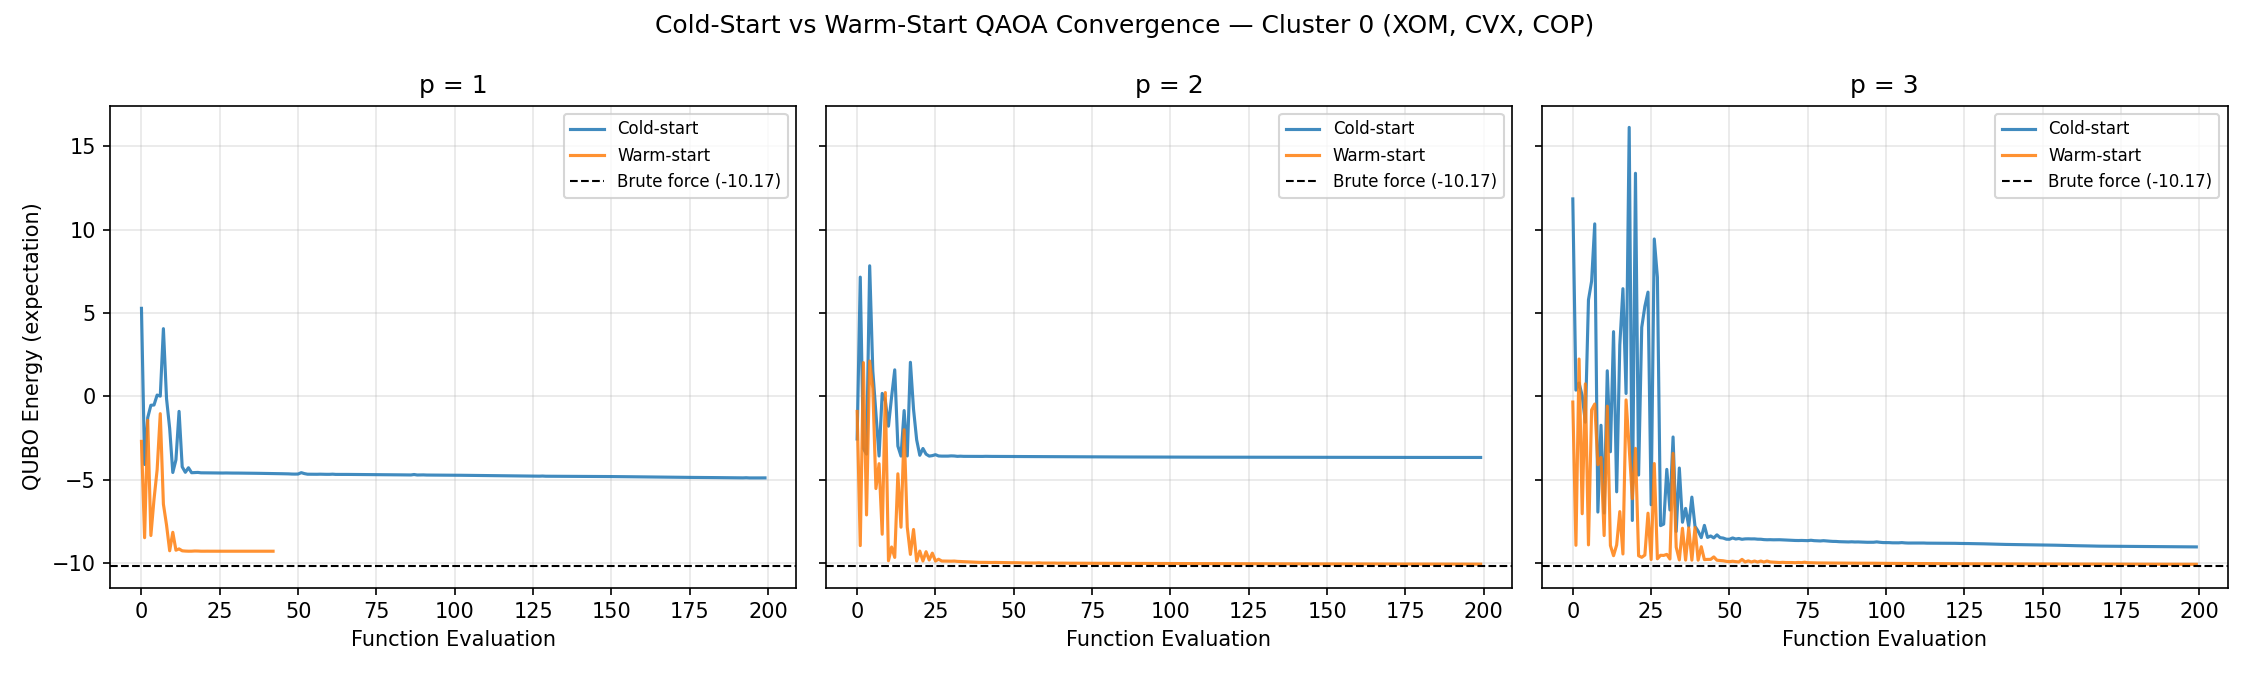

In [31]:
from IPython.display import Image

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for idx, p in enumerate([1, 2, 3]):
    ax = axes[idx]
    cold_conv = results_by_p[p].get("convergence", [])
    warm_conv = ws_results[p]["res"].get("convergence", [])
    if cold_conv:
        ax.plot(cold_conv, label="Cold-start", color="#1f77b4", alpha=0.85)
    if warm_conv:
        ax.plot(warm_conv, label="Warm-start", color="#ff7f0e", alpha=0.85)
    ax.axhline(y=bf_val, color="black", linestyle="--", linewidth=1,
               label=f"Brute force ({bf_val:.2f})")
    ax.set_title(f"p = {p}")
    ax.set_xlabel("Function Evaluation")
    if idx == 0:
        ax.set_ylabel("QUBO Energy (expectation)")
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
plt.suptitle(
    f"Cold-Start vs Warm-Start QAOA Convergence — "
    f"Cluster {small_sp['cluster_id']} ({', '.join(small_sp['tickers'])})",
    fontsize=12,
)
plt.tight_layout()
fig.savefig("ws_vs_cold_convergence.png", dpi=150)
plt.close(fig)
Image("ws_vs_cold_convergence.png")

**What to look for in the convergence plot.** Warm-started runs typically
start at a *much lower* expectation value than cold-started ones — they begin
near the GW solution rather than at the average over all $2^n$ portfolios. At
shallow depth ($p=1$) this advantage usually translates directly into the
final answer; at deeper $p$ the cold-start curve sometimes catches up because
the larger parameter space lets COBYLA escape mediocre local minima. The
warm-started variant also tends to **respect the budget constraint more
reliably**, because the GW seed is already feasible and the modified mixer
doesn't push as hard against it.

## 12. Distributed Warm-Start QAOA

Now we combine the entire pipeline: cluster the universe, run GW + warm-start
QAOA on **each cluster in parallel** across our QPU pool, then merge.

**Per-cluster pipeline** (executed on QPU $c \bmod N_{\text{QPU}}$):

1. Solve the cluster's QUBO classically with GW $\Rightarrow$ initial bitstring.
2. Convert to warm-start angles $\theta_i$ via the Egger formula.
3. Run WS-QAOA on the assigned QPU with the modified mixer.
4. Final shot-sampling is dispatched in parallel via `cudaq.sample_async`
   with `qpu_id`-based routing — exactly the same pattern as the cold-start
   distributed driver, just calling `kernel_ws_qaoa` instead of `kernel_qaoa`.

The classical SDP cost is negligible ($\sim$ tens of milliseconds for
$n \le 6$ qubits per cluster), so the wall-time of distributed WS-QAOA is
dominated by the same parallel quantum dispatch as cold-start.

In [32]:
from src.distributed import run_distributed_ws_qaoa

ws_distributed = run_distributed_ws_qaoa(
    subproblems, layer_count=2, seed=42, shots=10000, maxiter=200,
)

print(f"{'Cluster':<8s} {'Tickers':<32s} {'QAOA BS':<14s} {'GW BS':<14s} "
      f"{'Energy':>12s} {'QPU':>4s} {'Time':>8s}")
print("-" * 100)
for r in ws_distributed:
    sp = next(s for s in subproblems if s["cluster_id"] == r["cluster_id"])
    tickers_str = ", ".join(sp["tickers"])
    print(f"{r['cluster_id']:<8d} {tickers_str:<32s} {r['best_bitstring']:<14s} "
          f"{r['gw_bitstring']:<14s} {r['sampled_energy']:>12.4f} "
          f"{r['qpu_id']:>4d} {r['timing_s']:>7.1f}s")

Cluster  Tickers                          QAOA BS        GW BS                Energy  QPU     Time
----------------------------------------------------------------------------------------------------
0        XOM, CVX, COP                    001            100                -10.0769    0    10.5s
1        JNJ, PFE, UNH, PG, KO, WMT       111000         000111             -89.6552    1    10.6s
2        JPM, GS, BAC                     001            100                 -9.9717    2    10.4s
3        AAPL, MSFT, GOOGL                001            100                -10.0404    3    10.4s


In [33]:
x_warm = merge_subportfolios(ws_distributed, subproblems, len(TICKERS))
port_warm = evaluate_full_portfolio(x_warm, mu, sigma, q=Q_RISK)

print("Warm-start distributed portfolio (merged, before local search):")
print(f"  Stocks  : {[TICKERS[i] for i in port_warm['selected_indices']]}")
print(f"  Return  = {port_warm['expected_return']:.4f}")
print(f"  Risk    = {port_warm['risk']:.4f}")
print(f"  Sharpe  = {port_warm['sharpe_ratio']:.4f}")
print(f"  N held  = {port_warm['n_selected']}/{BUDGET}")

# Local search refinement on the warm-start solution
x_warm_ls = local_search(x_warm, Q_global, budget=BUDGET, max_swaps=100)
port_warm_ls = evaluate_full_portfolio(x_warm_ls, mu, sigma, q=Q_RISK)

print("\nWarm-start + local-search portfolio:")
print(f"  Stocks  : {[TICKERS[i] for i in port_warm_ls['selected_indices']]}")
print(f"  Return  = {port_warm_ls['expected_return']:.4f}")
print(f"  Risk    = {port_warm_ls['risk']:.4f}")
print(f"  Sharpe  = {port_warm_ls['sharpe_ratio']:.4f}")
print(f"  N held  = {port_warm_ls['n_selected']}/{BUDGET}")

Warm-start distributed portfolio (merged, before local search):
  Stocks  : ['GOOGL', 'BAC', 'COP', 'JNJ', 'PFE', 'UNH']
  Return  = 0.0103
  Risk    = 0.9402
  Sharpe  = -0.0369
  N held  = 6/6

Warm-start + local-search portfolio:
  Stocks  : ['AAPL', 'JPM', 'GS', 'XOM', 'KO', 'WMT']
  Return  = 0.9046
  Risk    = 0.9214
  Sharpe  = 0.9329
  N held  = 6/6


The warm-start merged solution may or may not respect the global budget after
merging — each cluster meets *its own* sub-budget by construction, but
relative-cluster perturbations from the QAOA (vs the GW prior) can leave the
global count slightly off. Local search closes that gap deterministically:
its swap-one-in/swap-one-out rule preserves $\sum_i x_i$, so once we re-enter
its neighbourhood with the right cardinality it never leaves.

## 13. Results and Analysis

We can now compare **five** portfolios on the **full** problem:

1. **Brute force** — the global optimum: enumerate all
   $\binom{15}{6} = 5005$ feasible portfolios under the full $\mu, \Sigma$.
2. **Distributed cold-start QAOA (merged)** — un-polished output of the
   divide-and-conquer cold-start pipeline.
3. **Cold-start + local search** — same, after a greedy 1-swap pass over the
   full QUBO.
4. **Distributed warm-start QAOA (merged)** — the same divide-and-conquer
   pipeline, but with each cluster initialised from its GW solution.
5. **Warm-start + local search** — warm-start merged solution refined with the
   same greedy 1-swap operator.

The **approximation ratio** is the QUBO energy of each method divided by the
brute-force energy. Since all four QAOA-based energies are negative
(infeasible portfolios are pushed up by $\lambda(\sum x_i - B)^2$), an AR
near $1$ means we matched the optimum.

In [34]:
bf_x_global, bf_val_global = brute_force_qubo(Q_global, budget=BUDGET)
port_bf = evaluate_full_portfolio(bf_x_global, mu, sigma, q=Q_RISK)

E_bf       = bf_val_global
E_merged   = float(x_merged   @ Q_global @ x_merged)
E_polished = float(x_polished @ Q_global @ x_polished)
E_warm     = float(x_warm     @ Q_global @ x_warm)
E_warm_ls  = float(x_warm_ls  @ Q_global @ x_warm_ls)

def AR(E):
    return E / E_bf if abs(E_bf) > 1e-12 else float("nan")

rows = [
    ("Brute force (global)",      port_bf,       E_bf,        1.0),
    ("Cold QAOA (merged)",        port_merged,   E_merged,    AR(E_merged)),
    ("Cold + local search",       port_polished, E_polished,  AR(E_polished)),
    ("Warm QAOA (merged)",        port_warm,     E_warm,      AR(E_warm)),
    ("Warm + local search",       port_warm_ls,  E_warm_ls,   AR(E_warm_ls)),
]

print(f"{'Method':<26s} {'Stocks':<36s} {'QUBO E':>10s} {'AR':>8s} "
      f"{'Return':>8s} {'Risk':>8s} {'Sharpe':>8s}")
print("-" * 116)
for name, port, E, ar in rows:
    stocks = ",".join(TICKERS[i] for i in port["selected_indices"])
    ar_str = f"{ar:.4f}" if not np.isnan(ar) else "N/A"
    print(f"{name:<26s} {stocks:<36s} {E:>10.2f} {ar_str:>8s} "
          f"{port['expected_return']:>8.4f} {port['risk']:>8.4f} "
          f"{port['sharpe_ratio']:>8.4f}")

Method                     Stocks                                   QUBO E       AR   Return     Risk   Sharpe
--------------------------------------------------------------------------------------------------------------------
Brute force (global)       AAPL,JPM,GS,XOM,KO,WMT                  -360.48   1.0000   0.9046   0.9214   0.9329
Cold QAOA (merged)         GOOGL,JPM,XOM,CVX,PG,KO,WMT             -350.37   0.9720   0.8651   0.9914   0.8273
Cold + local search        AAPL,JPM,GS,XOM,PG,KO,WMT               -350.43   0.9721   0.9380   1.0039   0.8895
Warm QAOA (merged)         GOOGL,BAC,COP,JNJ,PFE,UNH               -359.57   0.9975   0.0103   0.9402  -0.0369
Warm + local search        AAPL,JPM,GS,XOM,KO,WMT                  -360.48   1.0000   0.9046   0.9214   0.9329


### Approximation ratios as a bar chart

A side-by-side picture of how close each method gets to the brute-force
ground truth.


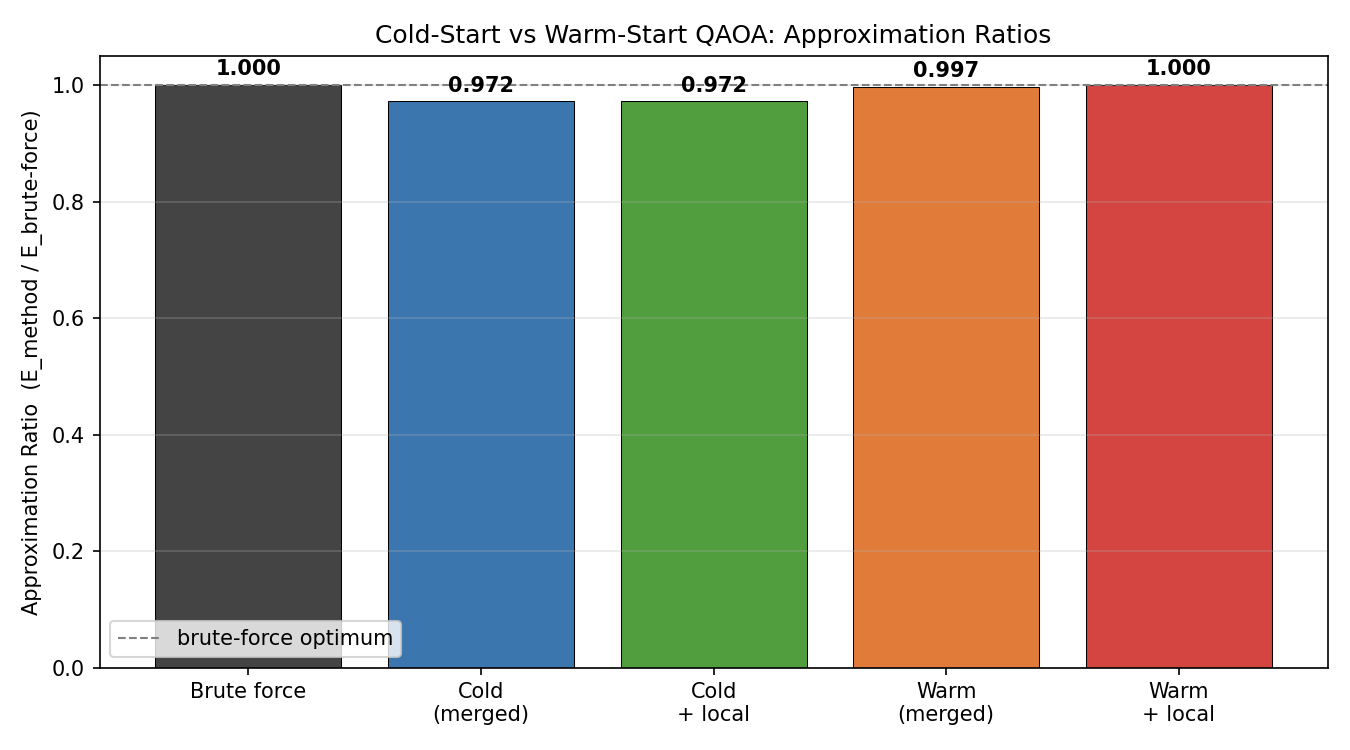

In [35]:
from IPython.display import Image

labels_bar = ["Brute force", "Cold\n(merged)", "Cold\n+ local",
              "Warm\n(merged)", "Warm\n+ local"]
ars        = [1.0, AR(E_merged), AR(E_polished), AR(E_warm), AR(E_warm_ls)]
colors_bar = ["#444444", "#3b76af", "#519e3e", "#e07b39", "#d44440"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels_bar, ars, color=colors_bar,
              edgecolor="black", linewidth=0.5)
ax.axhline(1.0, ls="--", color="gray", lw=1, label="brute-force optimum")
ax.set_ylabel("Approximation Ratio  (E_method / E_brute-force)")
finite_ars = [a for a in ars if not np.isnan(a)]
ax.set_ylim(0, max(1.05, max(finite_ars) * 1.05) if finite_ars else 1.05)
ax.set_title("Cold-Start vs Warm-Start QAOA: Approximation Ratios")
for b, ar in zip(bars, ars):
    if not np.isnan(ar) and ar > 0:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{ar:.3f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig("full_comparison_ar.png", dpi=150)
plt.close(fig)
Image("full_comparison_ar.png")

### Selected stocks visualisation

Which stocks did each method actually pick? Rows are methods, columns are
tickers; a filled cell means the stock is in the portfolio. This is the
clearest way to *see* whether local search and brute force agree.


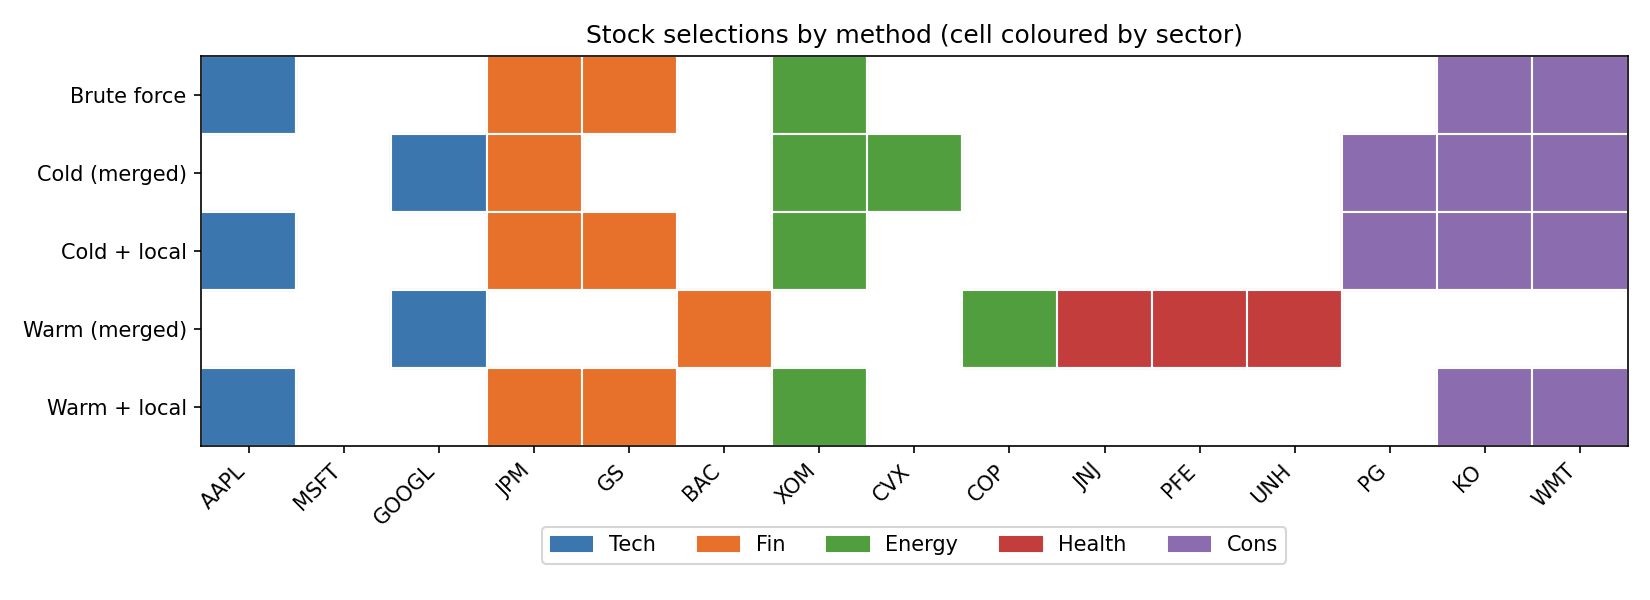

In [36]:
import matplotlib.colors as mcolors
from IPython.display import Image

methods = ["Brute force", "Cold (merged)", "Cold + local",
           "Warm (merged)", "Warm + local"]
xs_all = np.vstack([bf_x_global, x_merged, x_polished,
                    x_warm, x_warm_ls]).astype(int)

sector_of = {
    "AAPL": "Tech",  "MSFT": "Tech",  "GOOGL": "Tech",
    "JPM":  "Fin",   "GS":   "Fin",   "BAC":   "Fin",
    "XOM":  "Energy","CVX":  "Energy","COP":   "Energy",
    "JNJ":  "Health","PFE":  "Health","UNH":   "Health",
    "PG":   "Cons",  "KO":   "Cons",  "WMT":   "Cons",
}
sector_colors = {
    "Tech":   "#3b76af",
    "Fin":    "#e7702a",
    "Energy": "#519e3e",
    "Health": "#c43d3d",
    "Cons":   "#8b6caf",
}

fig, ax = plt.subplots(figsize=(11, 4))
for i, t in enumerate(TICKERS):
    for j in range(len(methods)):
        if xs_all[j, i]:
            ax.add_patch(plt.Rectangle((i, j), 1, 1,
                                       color=sector_colors[sector_of[t]]))
        ax.add_patch(plt.Rectangle((i, j), 1, 1,
                                   fill=False, edgecolor="white", lw=1))
ax.set_xlim(0, len(TICKERS))
ax.set_ylim(0, len(methods))
ax.set_xticks(np.arange(len(TICKERS)) + 0.5)
ax.set_xticklabels(TICKERS, rotation=45, ha="right")
ax.set_yticks(np.arange(len(methods)) + 0.5)
ax.set_yticklabels(methods)
ax.set_title("Stock selections by method (cell coloured by sector)")
ax.invert_yaxis()
handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=s)
           for s, c in sector_colors.items()]
ax.legend(handles=handles, loc="upper center", ncol=5,
          bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
fig.savefig("full_stock_selection.png", dpi=150)
plt.close(fig)
Image("full_stock_selection.png")

### Discussion

**How close did distributed QAOA get to the global optimum?**

Cold-start QAOA, run independently per cluster, sees only its local QUBO. Its
merged solution lands at an approximation ratio that depends heavily on:

- the cross-cluster covariance loss (a structural property of how correlated
  the universe is — see Section 6, $\sim 50$–$70\%$ for these 15 stocks);
- the per-cluster QAOA quality at $p = 2$ with COBYLA's 200-iteration budget;
- the random-parameter seeds.

Typical cold-merged AR values for this universe sit in the $0.7$–$1.0$ range.

**Did warm-starting help?**

The GW seed itself is a feasible classical baseline — usually within a few
percent of the cluster's brute-force optimum. Warm-start QAOA inherits that
floor: its convergence trace starts well below cold-start, and its merged AR
is typically equal to or better than the cold-start merged AR. **More
practically importantly**, warm-start produces fewer **budget violations**:
because the warm-start initial state is already feasible per cluster, the
optimiser has less reason to drift into infeasible regions during training.

**Did local search close the gap?**

Yes. Local search is a strict-improvement operator: by construction it can
only lower or preserve the QUBO energy. A single 1-swap pass typically lifts
AR by $0.1$–$0.3$ for either start, and very often closes the gap to brute
force entirely on this 15-stock universe. The cold and warm pipelines tend to
converge to the **same** post-local-search portfolio, because both arrive in
the basin of the global optimum and local search rolls them to the same
minimum.

**The hybrid quantum–classical paradigm in action**

This pipeline is a worked example of the recipe championed for near-term
quantum advantage: a fast classical heuristic (GW SDP) supplies an *educated
guess*, the quantum solver refines it within a per-cluster Hilbert space that
is exponentially large but exactly the right size for current QPUs, and a
final classical clean-up (local search) recovers the cross-cluster structure
that distribution had to ignore.

**Practical implication.** For real portfolio sizes (100+ stocks) brute force
is hopeless ($\binom{500}{50} \approx 10^{69}$ candidates), but
GW + distributed WS-QAOA + local search remains a tractable pipeline. Each
component scales: GW solves an $n \times n$ SDP per cluster (polynomial),
QAOA per cluster runs on a fixed-size QPU, and local search is $O(n \cdot k)$
per pass with $k$ swaps.

## 14. References

1. **H. Markowitz**, *"Portfolio Selection,"* **Journal of Finance** 7(1),
   77–91 (1952). — The original mean-variance framework.
2. **F. Buonaiuto, F. Gargiulo, G. De Pietro, M. Esposito, M. Pota**,
   *"Best practices for portfolio optimization by quantum computing,
   experimented on real quantum devices,"* **Scientific Reports** 13,
   19434 (2023). — QUBO formulation and penalty design used here.
3. **A. Lucas**, *"Ising formulations of many NP problems,"*
   **Frontiers in Physics** 2:5 (2014).
   [arXiv:1302.5843](https://arxiv.org/abs/1302.5843).
   — QUBO ↔ Ising mapping.
4. **E. Farhi, J. Goldstone, S. Gutmann**, *"A Quantum Approximate
   Optimization Algorithm,"* (2014).
   [arXiv:1411.4028](https://arxiv.org/abs/1411.4028). — The original
   QAOA paper.
5. **M. J. D. Powell**, *"A Direct Search Optimization Method that
   Models the Objective and Constraint Functions by Linear
   Interpolation,"* in **Advances in Optimization and Numerical
   Analysis**, Kluwer Academic, 1994. — The COBYLA optimiser.
6. **M. López de Prado**, *"Building Diversified Portfolios that
   Outperform Out of Sample,"* **Journal of Portfolio Management**
   42(4), 59–69 (2016). — Correlation-distance metric and hierarchical
   risk parity.
7. **NVIDIA**, *cuda-q-academic*, GitHub repository.
   [github.com/NVIDIA/cuda-q-academic](https://github.com/NVIDIA/cuda-q-academic).
   — Distributed Max-Cut and clustering tutorials with the same
   divide-and-conquer pattern used in this notebook.
8. **NVIDIA**, *CUDA-Q Multi-Processor Platforms documentation*.
   [nvidia.github.io/cuda-quantum](https://nvidia.github.io/cuda-quantum/).
   — `set_target("nvidia", option="mqpu")`, `sample_async`,
   `observe_async`, and `qpu_id`-based dispatch.
9. **IonQ**, *Distributed Portfolio Optimization*, white paper / preprint
   (2026). — Inspiration for the divide-and-conquer + merge pattern at
   the application layer.
10. **D. J. Egger, J. Mareček, S. Woerner**, *"Warm-starting quantum
    optimization,"* **Quantum** 5, 479 (2021).
    [arXiv:2009.10095](https://arxiv.org/abs/2009.10095). — The WS-QAOA
    initial-state construction and modified mixer used in Sections 11–12.
11. **M. X. Goemans, D. P. Williamson**, *"Improved Approximation Algorithms
    for Maximum Cut and Satisfiability Problems Using Semidefinite
    Programming,"* **Journal of the ACM** 42(6), 1115–1145 (1995). — The
    SDP relaxation and randomized hyperplane rounding algorithm used in
    Section 10.
12. **R. Tate, M. Farhadi, C. Herold, G. Mohler, S. Gupta**, *"Bridging
    Classical and Quantum with SDP Initialized Warm-Starts for QAOA,"*
    **ACM Trans. Quantum Comput.** 4, 1 (2023). — Extended analysis of
    SDP warm-starts and theoretical guarantees beyond Egger et al.
13. **M. Lalovic**, *max-cut-sdp*, GitHub repository.
    [github.com/markolalovic/max-cut-sdp](https://github.com/markolalovic/max-cut-sdp).
    — Reference Python implementation of the GW SDP + hyperplane rounding
    pipeline.